Hola &#x1F600;

Soy **Hesus Garcia**, revisor de código de Practicum, y voy a examinar el proyecto que has desarrollado recientemente. Si encuentro algún error, te lo señalaré para que lo corrijas, ya que mi objetivo es ayudarte a prepararte para un ambiente de trabajo real, donde el líder de tu equipo actuaría de la misma manera. Si no puedes solucionar el problema, te proporcionaré más información en la próxima oportunidad. Cuando encuentres un comentario,  **por favor, no los muevas, no los modifiques ni los borres**. 

Revisaré cuidadosamente todas las implementaciones que has realizado para cumplir con los requisitos y te proporcionaré mis comentarios de la siguiente manera:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

</br>

**¡Empecemos!**  &#x1F680;


# ¿Qué vende un coche?

Eres un analista en Crankshaft List. Cientos de anuncios gratuitos de vehículos se publican en tu sitio web cada día. Necesitas estudiar los datos recopilados durante los últimos años y determinar qué factores influyen en el precio de un vehículo.

En el presente proyecto se evaluará los diferentes factores que influyen en el precio de los vehículos que se ofertan en la página web de Crankshaft List.
Se analizará los datos obtenidos de la página web de Crankshaft List...

## Tabla de contenidos

 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Gracias por incluir una tabla de contenido. Esto es una buena práctica que debemos seguir.
</div>


## Inicialización

In [1]:
# Cargando las librerías necesarias para el análisis.

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns


### Cargar datos

In [2]:
# Carga el archivo de datos en un DataFrame

try:
    df_vehicles = pd.read_csv('vehicles_us.csv')
except:
    df_vehicles = pd.read_csv('/datasets/vehicles_us.csv')

### Exploración de datos iniciales

El dataset contiene los siguientes campos:
- `price`
- `model_year`
- `model`
- `condition`
- `cylinders`
- `fuel` — gasolina, diesel, etc.
- `odometer` — el millaje del vehículo cuando el anuncio fue publicado
- `transmission`
- `paint_color`
- `is_4wd` — si el vehículo tiene tracción a las 4 ruedas (tipo Booleano)
- `date_posted` — la fecha en la que el anuncio fue publicado
- `days_listed` — desde la publicación hasta que se elimina


In [3]:
# Revisemos la estructura del dataset

df_vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


In [4]:
# Revisemos una muestra de datos

df_vehicles.sample(10)

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
5452,2500,2001.0,toyota camry,good,6.0,gas,249000.0,automatic,sedan,grey,NaN,2019-03-24,15
22272,7800,2010.0,gmc acadia,excellent,6.0,gas,138000.0,automatic,SUV,white,NaN,2019-03-10,24
9152,3500,2005.0,ford explorer,excellent,6.0,gas,149000.0,automatic,SUV,NaN,NaN,2018-05-07,22
6736,3500,2008.0,honda civic lx,excellent,4.0,gas,143000.0,automatic,sedan,black,NaN,2018-05-30,25
46877,47985,2017.0,ford f-250 sd,good,8.0,gas,27676.0,automatic,truck,silver,1.0,2019-03-29,33
7437,2500,2005.0,nissan sentra,excellent,4.0,gas,141000.0,automatic,sedan,NaN,NaN,2018-08-19,37
49878,28900,2011.0,ford f-350 sd,excellent,8.0,diesel,120000.0,automatic,truck,white,1.0,2018-06-19,8
20404,8500,2001.0,gmc sierra 1500,excellent,8.0,gas,186000.0,automatic,truck,orange,1.0,2019-03-27,45
29865,4500,2009.0,nissan altima,excellent,4.0,gas,219000.0,automatic,sedan,black,NaN,2018-12-23,8
24478,9995,NaN,toyota camry,excellent,4.0,gas,90948.0,automatic,sedan,silver,NaN,2018-06-15,23


In [5]:
# Cantidad de valores ausentes por columna
df_vehicles.isna().sum()

price               0
model_year       3619
model               0
condition           0
cylinders        5260
fuel                0
odometer         7892
transmission        0
type                0
paint_color      9267
is_4wd          25953
date_posted         0
days_listed         0
dtype: int64

 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto</div>


- Se detecta que cinco de las trece columnas contienen datos ausentes:
    - *'model_year'* $\to$ Podría determinarse a partir de otras variables como las características del vehículo (*'model', 'cylinders', 'transmission', 'is_4wd'*, etc.).
    - *'cylinders'* $\to$ Sin embargo, la columna *'model'* no tienen valores ausentes y se podría encontrar una relación. 
    - *'odometer'*
    - *'paint_color'*
    - *'is_4wd'* $\to$ El tipo de dato de esta variable figura como *'float64'* pero dada las características observadas, el tipo correcto debería ser *'boolean'*. En este caso, los valores ausentes podrían ser ceros. 
- Existen variables categóricas que podrían contener duplicados implícitos.


### Revisión de variables categóricas

#### Columna *'`model`'*

In [6]:
df_vehicles['model'].sort_values().unique()

array(['acura tl', 'bmw x5', 'buick enclave', 'cadillac escalade',
       'chevrolet camaro', 'chevrolet camaro lt coupe 2d',
       'chevrolet colorado', 'chevrolet corvette', 'chevrolet cruze',
       'chevrolet equinox', 'chevrolet impala', 'chevrolet malibu',
       'chevrolet silverado', 'chevrolet silverado 1500',
       'chevrolet silverado 1500 crew', 'chevrolet silverado 2500hd',
       'chevrolet silverado 3500hd', 'chevrolet suburban',
       'chevrolet tahoe', 'chevrolet trailblazer', 'chevrolet traverse',
       'chrysler 200', 'chrysler 300', 'chrysler town & country',
       'dodge charger', 'dodge dakota', 'dodge grand caravan',
       'ford econoline', 'ford edge', 'ford escape', 'ford expedition',
       'ford explorer', 'ford f-150', 'ford f-250', 'ford f-250 sd',
       'ford f-250 super duty', 'ford f-350 sd', 'ford f150',
       'ford f150 supercrew cab xlt', 'ford f250', 'ford f250 super duty',
       'ford f350', 'ford f350 super duty', 'ford focus', 'ford focus

- Se encontraron *duplicados implícitos*. Se procede a reemplazarlos.

In [7]:
df_vehicles['model'] = df_vehicles['model'].replace(
    ['ford f-150', 'ford f-250', 'ford f-250 sd', 'ford f-250 super duty', 'ford f-350 sd'],
    ['ford f150', 'ford f250', 'ford f250 sd', 'ford f250 sd', 'ford f350 sd'])
df_vehicles['model'].sort_values().unique()

array(['acura tl', 'bmw x5', 'buick enclave', 'cadillac escalade',
       'chevrolet camaro', 'chevrolet camaro lt coupe 2d',
       'chevrolet colorado', 'chevrolet corvette', 'chevrolet cruze',
       'chevrolet equinox', 'chevrolet impala', 'chevrolet malibu',
       'chevrolet silverado', 'chevrolet silverado 1500',
       'chevrolet silverado 1500 crew', 'chevrolet silverado 2500hd',
       'chevrolet silverado 3500hd', 'chevrolet suburban',
       'chevrolet tahoe', 'chevrolet trailblazer', 'chevrolet traverse',
       'chrysler 200', 'chrysler 300', 'chrysler town & country',
       'dodge charger', 'dodge dakota', 'dodge grand caravan',
       'ford econoline', 'ford edge', 'ford escape', 'ford expedition',
       'ford explorer', 'ford f150', 'ford f150 supercrew cab xlt',
       'ford f250', 'ford f250 sd', 'ford f250 super duty', 'ford f350',
       'ford f350 sd', 'ford f350 super duty', 'ford focus',
       'ford focus se', 'ford fusion', 'ford fusion se', 'ford mustang',


#### Columna *'`condition`'*

In [8]:
df_vehicles['condition'].sort_values().unique()

array(['excellent', 'fair', 'good', 'like new', 'new', 'salvage'],
      dtype=object)

- No se encontraró nada anormal.

#### Columna *'`fuel`'*

In [9]:
df_vehicles['fuel'].sort_values().unique()

array(['diesel', 'electric', 'gas', 'hybrid', 'other'], dtype=object)

- No se encontró nada anormal.

#### Columna *'`transmission`'*

In [10]:
df_vehicles['transmission'].sort_values().unique()

array(['automatic', 'manual', 'other'], dtype=object)

- No se encontró nada anormal.

#### Columna *'`type`'*

In [11]:
df_vehicles['type'].sort_values().unique()

array(['SUV', 'bus', 'convertible', 'coupe', 'hatchback', 'mini-van',
       'offroad', 'other', 'pickup', 'sedan', 'truck', 'van', 'wagon'],
      dtype=object)

- No se encontró nada anormal.

#### Columna *'`paint_color`'*

In [12]:
df_vehicles['paint_color'].sort_values().unique()

array(['black', 'blue', 'brown', 'custom', 'green', 'grey', 'orange',
       'purple', 'red', 'silver', 'white', 'yellow', nan], dtype=object)

- Se encontraron valores ausentes.

#### Columna *'`is_4wd`*

In [13]:
df_vehicles['is_4wd'].sort_values().unique()

array([ 1., nan])

- Se encntró valores ausentes. No obstante, estavariable debería ser booleana. Por lo tanto, los valores *'nan'* deberían representar cero.

### Conclusiones y siguientes pasos

- Existen cinco columnas con valores ausentes que podrían ser rellenados a partir de la relación con otras columnas.
- Existen seis columnas con variables categóricas.
- Se procederá a completar los valores ausentes.
    - En el caso de las variables numéricas se buscará relaciones con otras variables que no contengan valores ausentes.
    - En el caso de las variables categóricas, si no se puede encontrar relación con otras variables, se completará utilizando la moda de cada una de ellas.


## Tratar los valores ausentes (si hay)

Como ya se ha mencionado, la variable *'is_4wd'* es una variable categórica que contiene valores ausentes que sí dependen de un patrón puesto que, esta variable sólo podría admitir dos valores. Se procederá a completar los datos de acuerdo a este criterio.

### Columna *'is_4wd*

In [14]:
# Reemplazando valores ausentes de 'paint_color'.
df_vehicles['is_4wd'] = df_vehicles['is_4wd'].fillna(0)


In [15]:
# Comprobando que ya no existan valores ausentes
df_vehicles['model_year'].isna().sum()

3619

Para continuar nuestra evaluación, se verificará la existencia o no de patrones que hayan provocado la ausencia de estos datos.
Para verificarlo se procederá a comparar los datos del dataset original con aquel que resulta del excluir los valores ausentes. 

In [16]:
# Creando series con frecuencias relativas para cada variable del dataset original
df1_myr = df_vehicles['model_year'].value_counts(normalize=True)
df1_cyl = df_vehicles['cylinders'].value_counts(normalize=True)
df1_odo = df_vehicles['odometer'].value_counts(normalize=True)
df1_col = df_vehicles['paint_color'].value_counts(normalize=True)

# Creando dataset sin valores ausentes
df_vehicles_available = df_vehicles.dropna()

# Creando series con frecuencias relativas para cada variable del dataset sin valores ausentes
df2_myr = df_vehicles_available['model_year'].value_counts(normalize=True)
df2_cyl = df_vehicles_available['cylinders'].value_counts(normalize=True)
df2_odo = df_vehicles_available['odometer'].value_counts(normalize=True)
df2_col = df_vehicles_available['paint_color'].value_counts(normalize=True)

# Convirtiendo series a dataframe
df1_myr=df1_myr.to_frame().reset_index()
df1_cyl=df1_cyl.to_frame().reset_index()
df1_odo=df1_odo.to_frame().reset_index()
df1_col=df1_col.to_frame().reset_index()

df2_myr=df2_myr.to_frame().reset_index()
df2_cyl=df2_cyl.to_frame().reset_index()
df2_odo=df2_odo.to_frame().reset_index()
df2_col=df2_col.to_frame().reset_index()


In [17]:
# Comparando resultados para 'model_year'
pd.merge(df1_myr, df2_myr, on = 'index', how = "inner")

,index,model_year_x,model_year_y
0,2013.0,0.074083,0.072637
1,2012.0,0.072392,0.072269
2,2014.0,0.071974,0.071333
3,2011.0,0.070450,0.071366
4,2015.0,0.069365,0.068793
...,...,...,...
60,1958.0,0.000042,0.000033
61,1955.0,0.000021,0.000033
62,1948.0,0.000021,0.000033
63,1961.0,0.000021,0.000033


In [18]:
# Comparando resultados para 'cylinders'
pd.merge(df1_cyl, df2_cyl, on = 'index', how = "inner")

,index,cylinders_x,cylinders_y
0,8.0,0.342462,0.343829
1,6.0,0.339349,0.340320
2,4.0,0.299665,0.296764
3,10.0,0.011866,0.012134
4,5.0,0.005879,0.006117
5,3.0,0.000735,0.000802
6,12.0,0.000043,0.000033


In [19]:
# Comparando resultados para 'odometer'
pd.merge(df1_odo, df2_odo, on = 'index', how = "inner")

,index,odometer_x,odometer_y
0,0.0,0.004240,0.004279
1,140000.0,0.004194,0.004279
2,120000.0,0.004102,0.003677
3,130000.0,0.004079,0.004078
4,160000.0,0.003827,0.003543
...,...,...,...
13587,138580.0,0.000023,0.000033
13588,94624.0,0.000023,0.000033
13589,123321.0,0.000023,0.000033
13590,202627.0,0.000023,0.000033


In [20]:
# Comparando resultados para 'paint_color'
pd.merge(df1_col, df2_col, on = 'index', how = "inner")

,index,paint_color_x,paint_color_y
0,white,0.237328,0.238668
1,black,0.182025,0.181575
2,silver,0.147759,0.147346
3,grey,0.119196,0.119100
4,blue,0.105897,0.105362
5,red,0.104619,0.106264
6,green,0.033035,0.031756
7,brown,0.028941,0.028480
8,custom,0.027285,0.027577
9,yellow,0.006034,0.006084


Se verifica que las frecuencia relativas en todos los casos son similares con lo que quedaría descartado que exista algún patrón que esté provocando la ausencia de estos valores.

Procederemos a completar los valores ausentes de las variables identificadas.

 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien por verificar las frecuencias relativas</div>


Antes de proceder con el reemplazo de los valores ausentes se revisará la distribución de estas variables en el dataset que no contiene valores ausentes.

In [21]:
df_vehicles_available.describe()

,price,model_year,cylinders,odometer,is_4wd,days_listed
count,29916.000000,29916.000000,29916.000000,29916.000000,29916.000000,29916.000000
mean,12197.222189,2009.746557,6.134343,115458.763003,0.496457,39.635446
std,10152.572328,6.274394,1.659248,65299.301405,0.499996,28.106683
min,1.000000,1908.000000,3.000000,0.000000,0.000000,0.000000
25%,5000.000000,2006.000000,4.000000,69840.000000,0.000000,19.000000
50%,9000.000000,2011.000000,6.000000,113000.000000,0.000000,33.000000
75%,16900.000000,2014.000000,8.000000,155115.500000,1.000000,53.000000
max,375000.000000,2019.000000,12.000000,990000.000000,1.000000,267.000000


Se comprueba la existencia de máximos extremos que se pueden considerar atípicos. Por esta razón se elegirá la mediana como mejor representación de estas variables.

### Columna *'cylinders*

In [22]:
# Reemplazando valores ausentes de 'cylinders'.
median_cylinders = df_vehicles.groupby('model')['cylinders'].transform('median') 
df_vehicles['cylinders'].fillna(median_cylinders, inplace=True)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>Correcta </div>


In [23]:
# Comprobando que no hayan más valores ausentes
df_vehicles['cylinders'].isna().sum()

0

In [24]:
# Comprobando la coherencia de los resultados
df_vehicles.groupby('cylinders')['model'].count()

cylinders
3.0        34
4.0     15499
5.0       294
6.0     17435
8.0     17712
10.0      549
12.0        2
Name: model, dtype: int64

### Columna *'model_year'*

In [25]:
# Reemplazando valores ausentes de 'model_year'.
median_model_year = df_vehicles.groupby('model')['model_year'].transform('median') 
df_vehicles['model_year'].fillna(median_model_year, inplace=True)

In [26]:
# Comprobando que no hayan más valores ausentes
df_vehicles['model_year'].isna().sum()

0

### Columna *'odometer'*

In [27]:
# Reemplazando valores ausentes de 'odometer'.
median_odometer = df_vehicles.groupby('model_year')['odometer'].transform('median') 
df_vehicles['odometer'].fillna(median_odometer, inplace=True)

In [28]:
# Comprobando que no hayan más valores ausentes
df_vehicles['odometer'].isna().sum()

1

Hay un valor que no ha podido ser reemplazado. Revisaremos este caso.

In [29]:
# Verificando el único valor ausente que no pudo ser reemplazado
df_vehicles[df_vehicles['odometer'].isna()]

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
45694,18000,1929.0,ford f150,good,8.0,gas,NaN,manual,other,silver,0.0,2018-11-18,59


In [30]:
# Evaluando vecinos
df_vehicles.sort_values('model_year').head()

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
33907,12995,1908.0,cadillac escalade,excellent,8.0,gas,169328.0,automatic,SUV,white,0.0,2018-06-24,25
33906,12995,1908.0,gmc yukon,good,8.0,gas,169328.0,automatic,SUV,black,0.0,2018-07-06,34
45694,18000,1929.0,ford f150,good,8.0,gas,NaN,manual,other,silver,0.0,2018-11-18,59
34713,5000,1936.0,ford f150,excellent,6.0,gas,30000.0,manual,pickup,purple,0.0,2018-11-22,10
22595,21000,1948.0,chevrolet impala,like new,8.0,gas,4000.0,automatic,sedan,red,0.0,2019-01-18,24


- No había referencia para poder reemplazar el valor ausente para el año 1929. Se procederá a reemplazarlo manualmente.
- Se tomará como referencia el próximo dato siguiente ya que la diferencia en años es mucho menor al de su inmediato anterior.
- El valor ausente se reemplazará por 35000.

In [31]:
# Asignando valor al dato ausente
df_vehicles.loc[df_vehicles['model_year']==1929, 'odometer']=35000


In [32]:
# Comprobando que no hayan más valores ausentes
df_vehicles['odometer'].isna().sum()

0

### Columna *'paint_color'*

A diferencia de las variables anteriores, esta no puede ser evaluada por estadísticos numéricos. Por esta razón se utilizará la moda que representa el valor más se repite.

In [33]:
# Reemplazando valores ausentes de 'paint_color'.
mode_paint_color = df_vehicles.groupby('model')['paint_color'].agg(pd.Series.mode) 
mode_paint_color

model
acura tl               grey
bmw x5                black
buick enclave         white
cadillac escalade     black
chevrolet camaro        red
                      ...  
toyota sienna        silver
toyota tacoma         white
toyota tundra         white
volkswagen jetta     silver
volkswagen passat     black
Name: paint_color, Length: 97, dtype: object

In [34]:
# Creamos una función para rellenar los valores ausentes
def paint_color_nan(row):
    model=row['model']
    paint_color=row['paint_color']
    
    if pd.isna(paint_color):
        return mode_paint_color.loc[model]
    return paint_color

In [35]:
# Reemplazando valores ausentes de 'paint_color'.
df_vehicles['paint_color']= df_vehicles.apply(paint_color_nan, axis=1)

In [36]:
# Comprobando que no hayan más valores ausentes
df_vehicles['paint_color'].isna().sum()

0

## Corregir los tipos de datos

Como ya se había mencionado, la variable *'is_4wd'* tiene un tipo de dato equivocado. Sin embargo, no es la única. Las variables *'model_year'*, *'cylinders'*, *'odometer'* están declaradas como *'float'* cuando claramente son *'int'* y la variable *'date_posted'*, declarada como *'object'* cuando debe ser del tipo *'datetime'*.

Se procede a corregir los tipos de datos conforme lo explicado arriba.

In [37]:
df_vehicles['model_year'] = df_vehicles['model_year'].astype(int)
df_vehicles['cylinders'] = df_vehicles['cylinders'].astype(int)
df_vehicles['odometer'] = df_vehicles['odometer'].astype(int)
df_vehicles['is_4wd'] = df_vehicles['is_4wd'].astype(bool)
df_vehicles['date_posted'] = pd.to_datetime(df_vehicles['date_posted'], format='%Y-%m-%d')

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>Correcto. </div>


In [38]:
# Se comprueba los cambios efectuados
df_vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   price         51525 non-null  int64         
 1   model_year    51525 non-null  int32         
 2   model         51525 non-null  object        
 3   condition     51525 non-null  object        
 4   cylinders     51525 non-null  int32         
 5   fuel          51525 non-null  object        
 6   odometer      51525 non-null  int32         
 7   transmission  51525 non-null  object        
 8   type          51525 non-null  object        
 9   paint_color   51525 non-null  object        
 10  is_4wd        51525 non-null  bool          
 11  date_posted   51525 non-null  datetime64[ns]
 12  days_listed   51525 non-null  int64         
dtypes: bool(1), datetime64[ns](1), int32(3), int64(2), object(6)
memory usage: 4.2+ MB


## Enriquecer datos

Algunos datos adicionales como el año de publicación de los anuncios que al restarles el año de fabricación nos podrían dar la edad del vehículo o el millaje promedio podrían favorecer el análisis. Procederemos a calcularlos.

### Edad (años) de los vehículos

In [39]:
# Agrega los años del vehículo cuando el anuncio se colocó

df_vehicles['years_of_vehicle'] = df_vehicles['date_posted'].dt.year - df_vehicles['model_year']
df_vehicles.sample(5)

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle
48947,2995,1997,ford f150,fair,8,gas,183533,automatic,pickup,black,True,2018-07-05,36,21
40231,10995,2009,jeep grand cherokee laredo,excellent,8,gas,69935,automatic,SUV,silver,True,2019-04-09,5,10
11547,7590,2011,toyota prius,excellent,4,hybrid,128859,automatic,sedan,silver,False,2018-11-01,32,7
18864,4900,2012,chevrolet traverse,excellent,6,gas,170,automatic,SUV,green,False,2018-05-10,87,6
39122,16500,2016,honda cr-v,like new,4,gas,35555,automatic,SUV,white,True,2018-08-21,48,2




<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Calcularemos la columna de antigüedad del auto garantizado siempre un valor de 1 para evitar problemas al realizar cálculos. 

</div>


In [40]:
# Agrega el millaje promedio del vehículo por año

df_vehicles['annual_mileage']= df_vehicles['odometer']/df_vehicles['years_of_vehicle']
df_vehicles.sample(5)

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle,annual_mileage
22166,1400,2003,ford escape,salvage,6,gas,210000,automatic,SUV,grey,False,2019-01-13,134,16,13125.000000
5603,5900,2004,chevrolet silverado,good,8,diesel,156640,automatic,pickup,grey,True,2018-06-27,25,14,11188.571429
45316,2000,2010,ford fusion,good,6,gas,239000,automatic,sedan,silver,False,2018-09-13,41,8,29875.000000
43120,7500,2003,ram 2500,excellent,8,gas,161988,automatic,pickup,white,False,2018-05-04,12,15,10799.200000
34003,8399,2010,honda civic lx,excellent,4,gas,90500,automatic,sedan,grey,False,2018-11-20,31,8,11312.500000


In [41]:
# Comprobando que no hayan más valores ausentes
df_vehicles['annual_mileage'].isna().sum()


2

Se detectan dos valores ausentes. Esto era de esperarse dado que esta variable es un conciente cuyo divisor es la edad del vehículo y esta podría cero si el vehículo se vendió el mismo año de su fabricación.

Revisaremos estos errores y les daremos solución.

In [42]:
# Verificando valores ausentes
df_vehicles[df_vehicles['annual_mileage'].isna()]

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle,annual_mileage
17037,45400,2018,ram 3500,excellent,6,diesel,0,automatic,pickup,black,True,2018-12-16,18,0,NaN
40489,15900,2018,toyota prius,excellent,4,hybrid,0,automatic,hatchback,blue,False,2018-07-30,31,0,NaN


Efectivamente, los valores ausentes se dieron por un error de división por cero.
Se reemplazará estos NaN con ceros.

In [43]:
#Llenaremos con 0 esos valores ausentes ya que no hay millas ni años 
df_vehicles['annual_mileage']= df_vehicles['annual_mileage'].fillna(0)

In [44]:
# Comprobando que no hayan más valores ausentes
df_vehicles['annual_mileage'].isna().sum()

0

### Creación de *'id'* para la variable *'`condition`'*

- Reemplazar valores de condicion por un id

In [45]:
# Revisar valores que puede tomar la variable 'condition'
df_vehicles['condition'].unique()

array(['good', 'like new', 'fair', 'excellent', 'salvage', 'new'],
      dtype=object)

In [46]:
# Podría ser útil reemplazar los valores de condición con algo que se pueda manipular más fácilmente
# Se crea un diccionario con los valores
condition_dict = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}

# Se crea la funcion
def condition_id(condition):
    return condition_dict.get(condition)

# Se aplica la funcion
df_vehicles['condition_id'] = df_vehicles['condition'].apply(condition_id)

# Se comprueba
df_vehicles.sample(5)


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle,annual_mileage,condition_id
3074,10990,2008,chevrolet suburban,good,8,gas,180025,automatic,SUV,black,True,2018-05-15,71,10,1.800250e+04,2
19878,28900,2012,ram 2500,excellent,6,diesel,134000,automatic,truck,green,True,2019-02-05,85,7,1.914286e+04,3
27762,3995,2008,toyota camry,good,4,gas,140000,automatic,sedan,custom,False,2018-06-04,101,10,1.400000e+04,2
6337,22500,2019,nissan frontier crew cab sv,good,6,gas,26344,other,pickup,white,True,2019-01-18,19,0,inf,2
12079,16990,2007,ford expedition,excellent,8,gas,114047,automatic,SUV,white,False,2018-09-20,11,11,1.036791e+04,3




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto

</div>


## Comprobar datos limpios

Luego de toda la manipulación de los datos, revisemos como quedó el dataset objeto de nuestro análisis.

In [47]:
# imprime la información general/resumida sobre el DataFrame
df_vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   price             51525 non-null  int64         
 1   model_year        51525 non-null  int32         
 2   model             51525 non-null  object        
 3   condition         51525 non-null  object        
 4   cylinders         51525 non-null  int32         
 5   fuel              51525 non-null  object        
 6   odometer          51525 non-null  int32         
 7   transmission      51525 non-null  object        
 8   type              51525 non-null  object        
 9   paint_color       51525 non-null  object        
 10  is_4wd            51525 non-null  bool          
 11  date_posted       51525 non-null  datetime64[ns]
 12  days_listed       51525 non-null  int64         
 13  years_of_vehicle  51525 non-null  int64         
 14  annual_mileage    5152

In [48]:
# imprimir una muestra de datos
df_vehicles.sample(10)


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle,annual_mileage,condition_id
14851,11000,2011,chevrolet silverado 1500,excellent,8,gas,129800,automatic,pickup,white,True,2018-07-26,22,7,18542.857143,3
12235,6995,2013,hyundai elantra,excellent,4,gas,99404,automatic,sedan,silver,False,2019-01-17,21,6,16567.333333,3
33747,26900,2015,chevrolet silverado 1500,good,8,gas,78285,automatic,truck,black,True,2018-07-07,40,3,26095.000000,2
19950,11886,2017,ford fusion se,excellent,4,gas,72000,automatic,sedan,grey,False,2018-05-25,98,1,72000.000000,3
16573,36000,2012,ford f250,excellent,8,diesel,110000,automatic,pickup,white,True,2019-03-25,30,7,15714.285714,3
29614,18500,2014,ford f250,good,8,gas,90000,automatic,truck,white,True,2018-07-10,51,4,22500.000000,2
2190,6300,2009,nissan murano,excellent,6,gas,97000,automatic,SUV,black,False,2019-03-09,82,10,9700.000000,3
28749,26500,2011,chevrolet silverado 2500hd,excellent,8,diesel,199000,automatic,truck,white,True,2019-04-12,10,8,24875.000000,3
15591,7566,2013,dodge charger,excellent,8,gas,86720,automatic,sedan,silver,False,2018-07-20,32,5,17344.000000,3
2392,5800,2005,toyota corolla,excellent,6,gas,153069,automatic,sedan,brown,False,2018-12-23,80,13,11774.538462,3


## Estudiar parámetros principales

Los parámetros son:
- Precio
- Los años del vehículo cuando el anuncio se colocó
- Millaje
- Número de cilindros
- Estado

Los parámetros descritos arriba serán analizados mediante histogramas y gráficos de cajas con el fin de identificar si existen valores atípicos que podrían distorsionar los resultados del presente trabajo. Pero empezaremos por revisar la distribución de estos parámetros.

In [49]:
# Distribucion de los parámetros de estudio
df_vehicles_columns = df_vehicles[['price', 'years_of_vehicle', 'odometer', 'cylinders', 'condition_id']]
df_vehicles_columns.describe()

,price,years_of_vehicle,odometer,cylinders,condition_id
count,51525.000000,51525.000000,51525.000000,51525.000000,51525.000000
mean,12132.464920,8.512489,115201.154585,6.121067,2.637535
std,10040.803015,6.113039,62085.333823,1.657457,0.712447
min,1.000000,0.000000,0.000000,3.000000,0.000000
25%,5000.000000,4.000000,73500.000000,4.000000,2.000000
50%,9000.000000,7.000000,114072.000000,6.000000,3.000000
75%,16839.000000,12.000000,152811.000000,8.000000,3.000000
max,375000.000000,110.000000,990000.000000,12.000000,5.000000


### Análisis del parámetro **Precio** (*'`price`'*)
A partir de la distribución obtenida arriba, podemos observar que:
- El valor máximo es más de 22 veces el valor del tercer cuartil.
- El valor mínimo, a pesar de encontrarse bastante cerca del valor del primer cuartil (considerando las distancias intercuartílicas), es inverosímil. El valor mínimo admisible será evaluado más adelante.

Vamos a observar gráficamente este parámetro para ver la consistencia de los datos a lo largo de sus valores. 

Text(0.5, 0, 'Dólares')

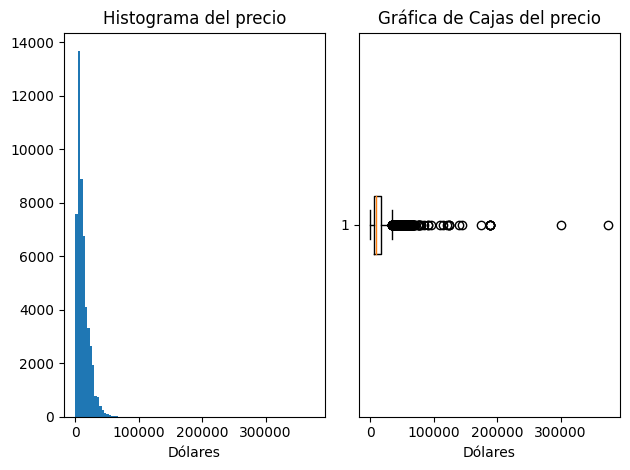

In [50]:
# Histograma y gráfica de cajas del parámetro 'price'.
price = df_vehicles['price']

fig, axs = plt.subplots(1, 2, tight_layout=True)

axs[0].hist(price, bins=100)
axs[0].set_title('Histograma del precio')
axs[0].set_xlabel('Dólares')
axs[1].boxplot(price, vert=False)
axs[1].set_title('Gráfica de Cajas del precio')
axs[1].set_xlabel('Dólares')



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. No olvides mencionar que utilizaste la regla de scott para generar tu histograma. 
</div>


Queda claro que los valores atípicos son extremos y que no tienen representatividad pues ni siquiera se notan en el histograma. Sin embargo, si nos detenemos un poco en el gráfico de cajas veremos una nube de puntos justo desde el valor máximo admisible hasta más o menos un valor igual a 70000. Para despejar la duda que podría provocar esta gráfica observaremos más de cerca esta distribución pero en este caso la veremos por el tipo de vehículo.

[Text(0.5, 1.0, 'Distribución del precio según el tipo de vehículo')]

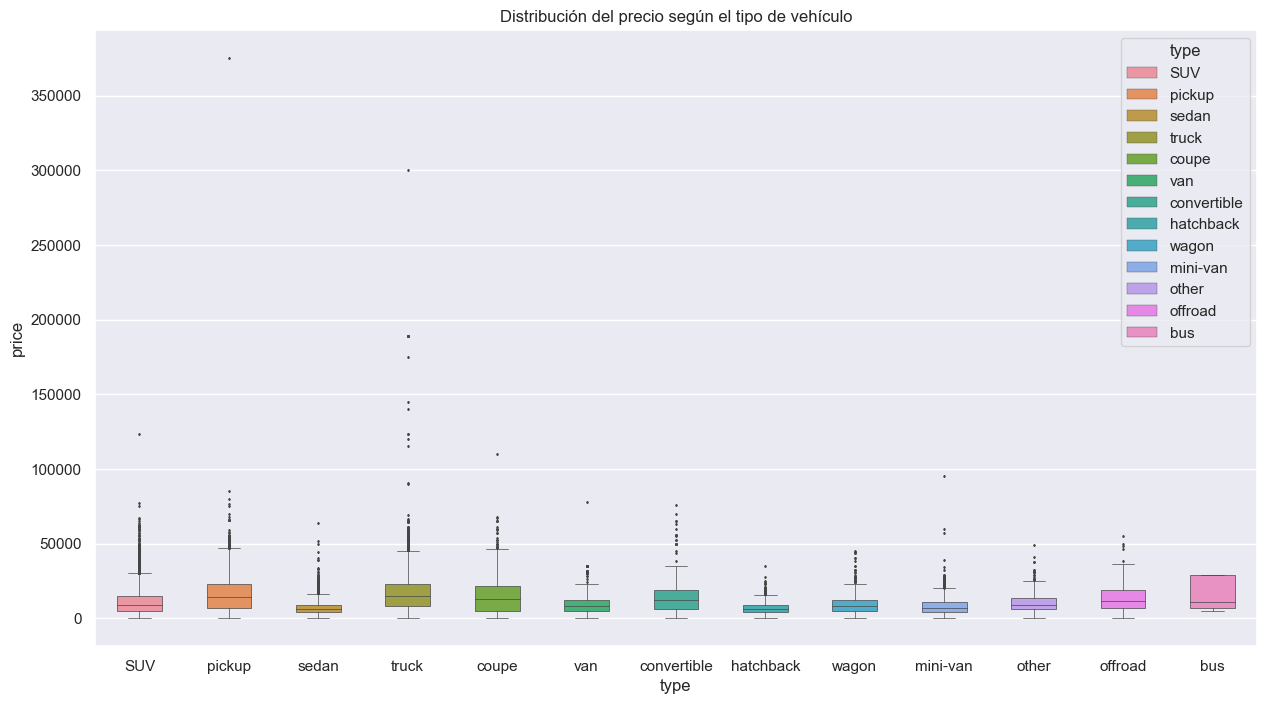

In [51]:
# Grafica de cajas de la distribución del precio por tipo de vehículo.
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_vehicles, x='type', y='price', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del precio según el tipo de vehículo')

Con este gráfico ya no queda duda que en ningún caso se pueden considerar valores por encima de 50000.

### Análisis del parámetro **Años del vehículo** (*'`years_of_vehicle`'*)
A partir de la distribución obtenida arriba, podemos observar que:
- El valor máximo llega a 110 años, más de 9 veces el valor del tercer cuartil.
- El valor mínimo llega a cero. Esto es fácil de explicar puesto que en la exploración de los datos identificamos que hubieron vehículos cuyo año de fabricación coincidía con el año de venta.

Vamos a observar gráficamente este parámetro para ver la consistencia de los datos a lo largo de sus valores. 

Text(0.5, 0, 'Años')

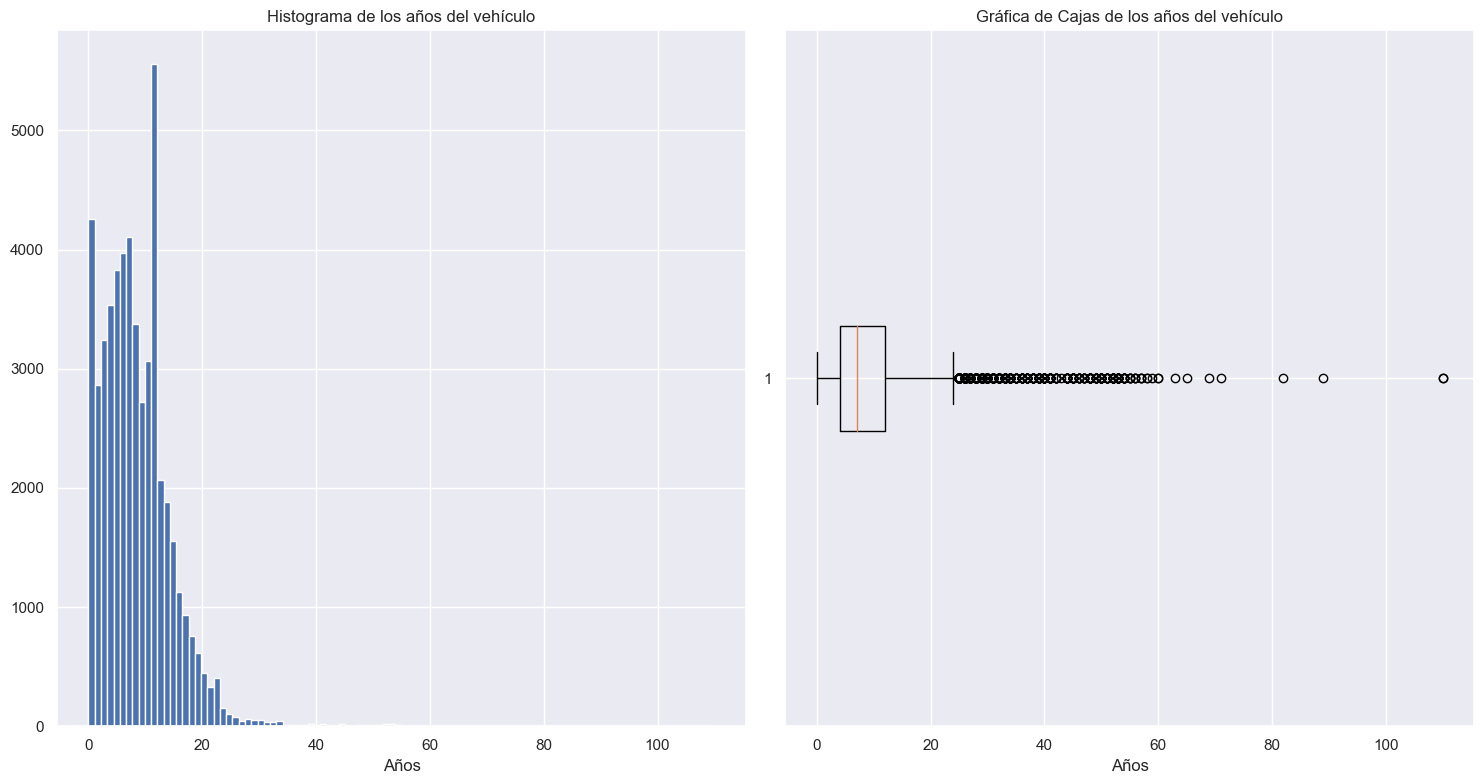

In [52]:
# Histograma y gráfica de cajas del parámetro 'years_of_vehicle'.
years = df_vehicles['years_of_vehicle']

fig, axs = plt.subplots(1, 2, tight_layout=True)

axs[0].hist(years, bins=100)
axs[0].set_title('Histograma de los años del vehículo')
axs[0].set_xlabel('Años')
axs[1].boxplot(years, vert=False)
axs[1].set_title('Gráfica de Cajas de los años del vehículo')
axs[1].set_xlabel('Años')

Al igual que en el caso anterior, se comprueba que los valores atípicos son extremos y que no tienen representatividad. A pesar que en este caso, los valores por encima del valor máximo admisible están más dispersos, utilizaremos de nuevo el parámetro *tipo de vehículo* *('type')* para comprobarlo.

[Text(0.5, 1.0, 'Distribución de los años del vehículo según el tipo de vehículo')]

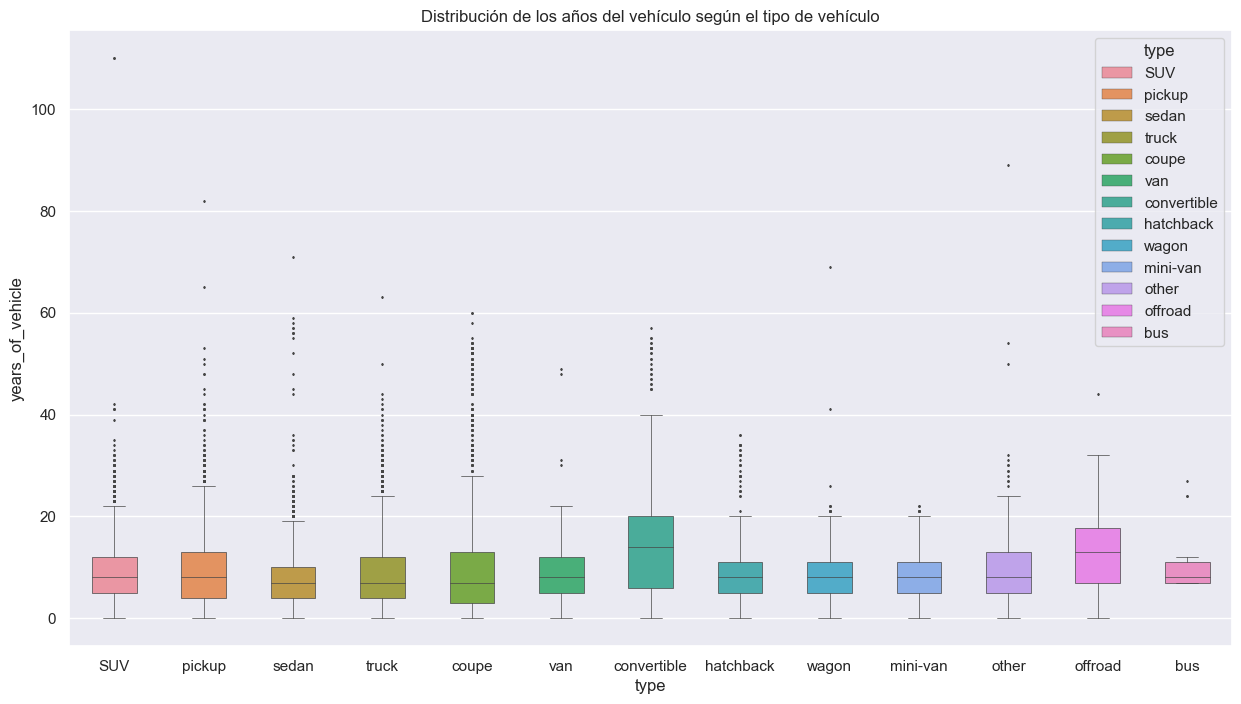

In [53]:
# Grafica de cajas de la distribución de los años del vehículo por tipo de vehículo.
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_vehicles, x='type', y='years_of_vehicle', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución de los años del vehículo según el tipo de vehículo')



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. 
</div>


Se puede notar que los valores máximos admisibles, por lo general se encuentran entre 20 y 40 años.

### Análisis del parámetro **Millaje** (*'`odometer`'*)
A partir de la distribución obtenida arriba, podemos observar que:
- El valor máximo representa más de 6 veces el valor del tercer cuartil.
- El valor mínimo llega a cero. Aunque existen vehículo cuyos años de fabricación y de venta coinciden es difícil pensar que no hayan tenido ningún recorrido. El valor mínimo admisible sera evaluado más adelante.

Vamos a observar gráficamente este parámetro para ver la consistencia de los datos a lo largo de sus valores. 

Text(0.5, 0, 'Millas')

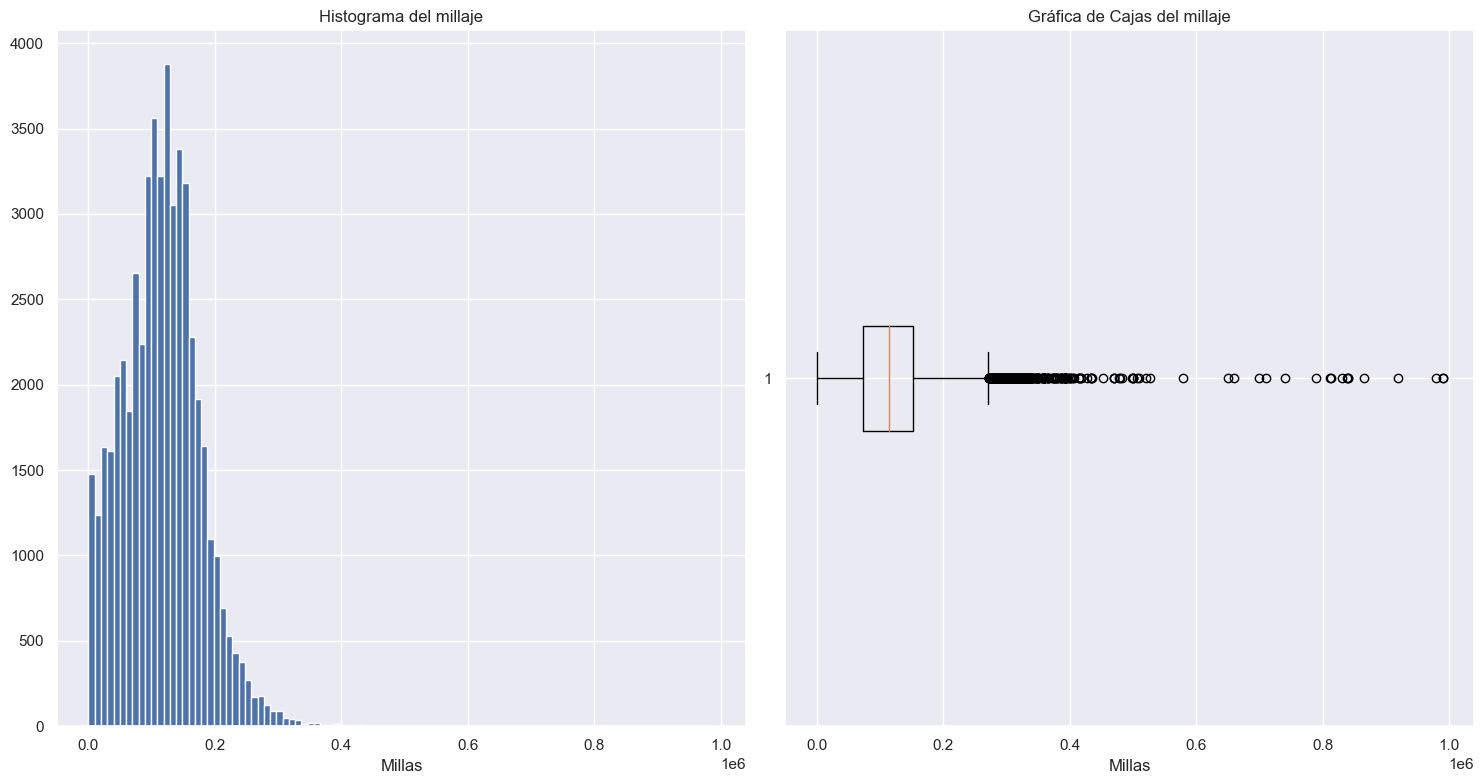

In [54]:
# Histograma y gráfica de cajas del parámetro 'odometer'.
mileage = df_vehicles['odometer']

fig, axs = plt.subplots(1, 2, tight_layout=True)

axs[0].hist(mileage, bins=100)
axs[0].set_title('Histograma del millaje')
axs[0].set_xlabel('Millas')
axs[1].boxplot(mileage, vert=False)
axs[1].set_title('Gráfica de Cajas del millaje')
axs[1].set_xlabel('Millas')

Nuevamente usaremos el parámetro *tipo de vehículo* *('type')* para revisar la nube de puntos aledaña al valor máximo admisible.

[Text(0.5, 1.0, 'Distribución del millaje según el tipo de vehículo')]

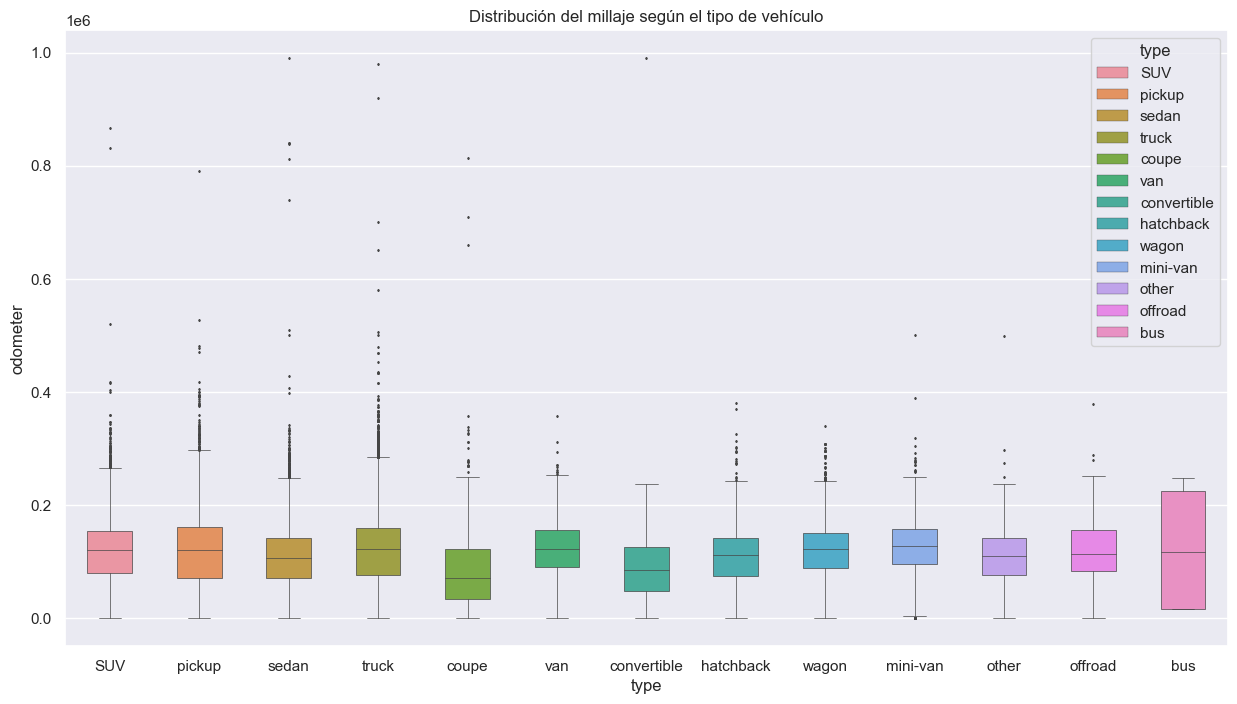

In [55]:
# Grafica de cajas de la distribución del millaje por tipo de vehículo.
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_vehicles, x='type', y='odometer', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del millaje según el tipo de vehículo')

Se aprecia que los valores máximos admisiblesse encuentran al rededor de las 300 mil millas.



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. 
</div>


### Análisis del parámetro **Cilindros** (*'`cylinders`'*)
Este parámetro es bastante discreto. La distribución obtenida arriba solo confirma los valores observados en la exploración de los datos. Por lo que no se justifica mayor análisis. No obstante, graficaremos su histograma para ver la representatividad de cada uno de los valores que toma este parámetro.

array([[<Axes: title={'center': 'cylinders'}>]], dtype=object)

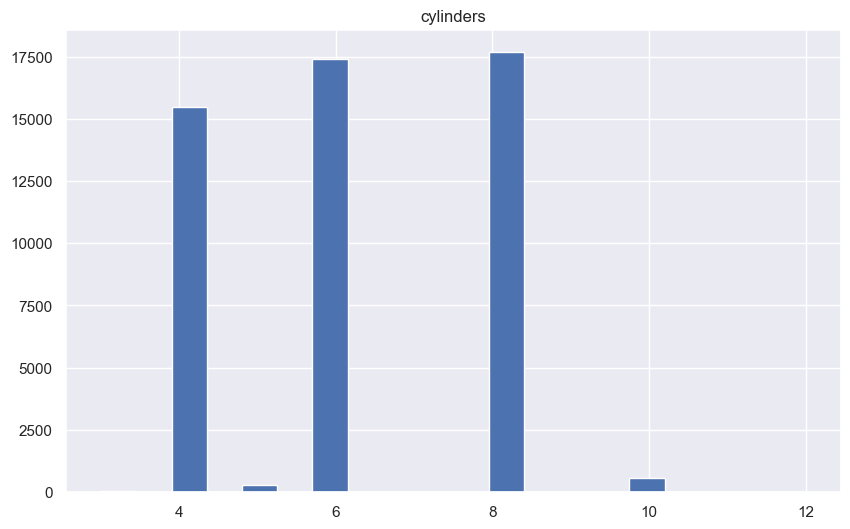

In [56]:
# Histograma de Cilindros
df_vehicles.hist(column=['cylinders'], figsize=(10,6), bins=20)



<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si bien se puede utilizar un histograma en variables discreta, categóricas y ordinales, podría no resultar la mejor opción. Es importante tener en cuenta que, en algunos casos, puede ser más apropiado utilizar otro tipo de gráfico para representar la distribución de variables categóricas, como un gráfico de barras o un gráfico de sectores. El tipo de gráfico más adecuado dependerá del tipo de datos y del objetivo de la visualización.
</div>


Las cilinrdradas más frecuentes son las 8, 6 y 4 cilindros en orden estrictamente descendiente. Por otro lado, las otras cilindradas a penas muestran valor.

### Análisis del parámetro **Estado** (*'`condition_id`'*)
Al igual que el parámetro *cilindros*, este parámetro es discreto y la distribución obtenida arriba ha confirmado lo observado en la exploración de los datos. Por lo que no se justifica mayor análisis. Sin embargo, al igual que en el caso anterior, sí nos interesa conocer la calidad del estado de los vehículos que se ofertan en la página web por lo que visualizaremos su histograma.

array([[<Axes: title={'center': 'condition_id'}>]], dtype=object)

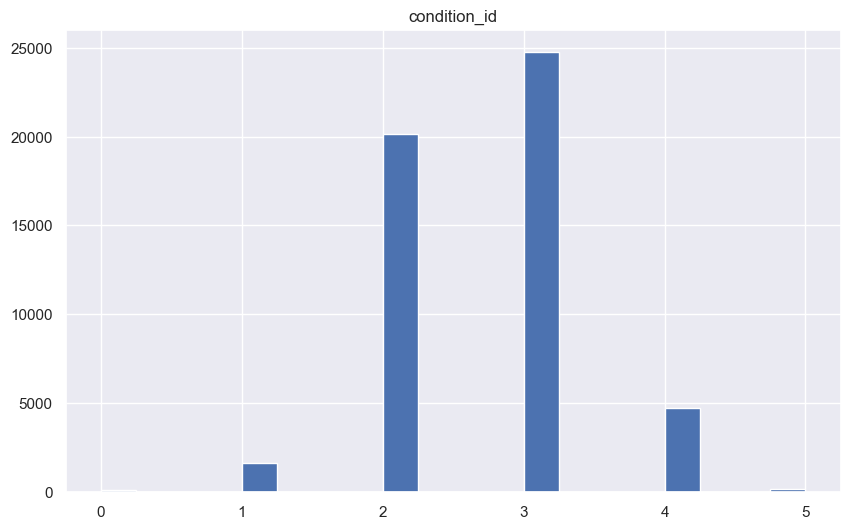

In [57]:
# Histograma del estado del vehículo (condition_id)
df_vehicles.hist(column=['condition_id'], figsize=(10,6), bins=20)

En este punto es importante recordar qué categoría representa cada uno de estos *id*.
- 0: 'salvage'
- 1: 'fair'
- 2: 'good'
- 3: 'excellent'
- 4: 'like new'
- 5: 'new'

Es satisfactorio ver que la mayoría de los vehículos tiene la condición de *excelente* o *bueno*.

## Estudiar y tratar valores atípicos

[Con los resultados anteriores, determina qué columnas pueden contener valores atípicos y crea un DataFrame sin esos valores atípicos. Pista: los valores atípicos se pueden identificar tras definir el límite inferior/superior para el rango normal de valores.]

Se utilizará los gráficos de **cajas y bigotes** para determinar los límites inferiores y superiores.

### Determinación de valores atípicos en la variable *'`precio`'*

#### Determinación del límite superior de la variable *'`price`'*

In [58]:
# Calculo el límite superior utilizando el criterio de IQR
price_lim_sup = 2.5*df_vehicles['price'].quantile(0.75)-1.5*df_vehicles['price'].quantile(0.25)
price_lim_sup

34597.5

- Como vimos arriba, uno de los tipos de vehículo tenía un valor máximo admisible cercano a 50000 por lo que el considerar como límite el obtenido para todo el conjunto no sería adecuado.
- Se calculará el límite superior para el tipo *'pickup'* que fue el que tuvo el mayor límite superior.



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. 
</div>


In [59]:
# Calculo el límite superior utilizando el criterio de IQR
df_vehicles_pick = df_vehicles.query('type == "pickup"')
price_lim_sup = 2.5*df_vehicles_pick['price'].quantile(0.75)-1.5*df_vehicles_pick['price'].quantile(0.25)
price_lim_sup

46997.5

[Text(0.5, 1.0, 'Gráfico de cajas para el precio de los vehículos pickup')]

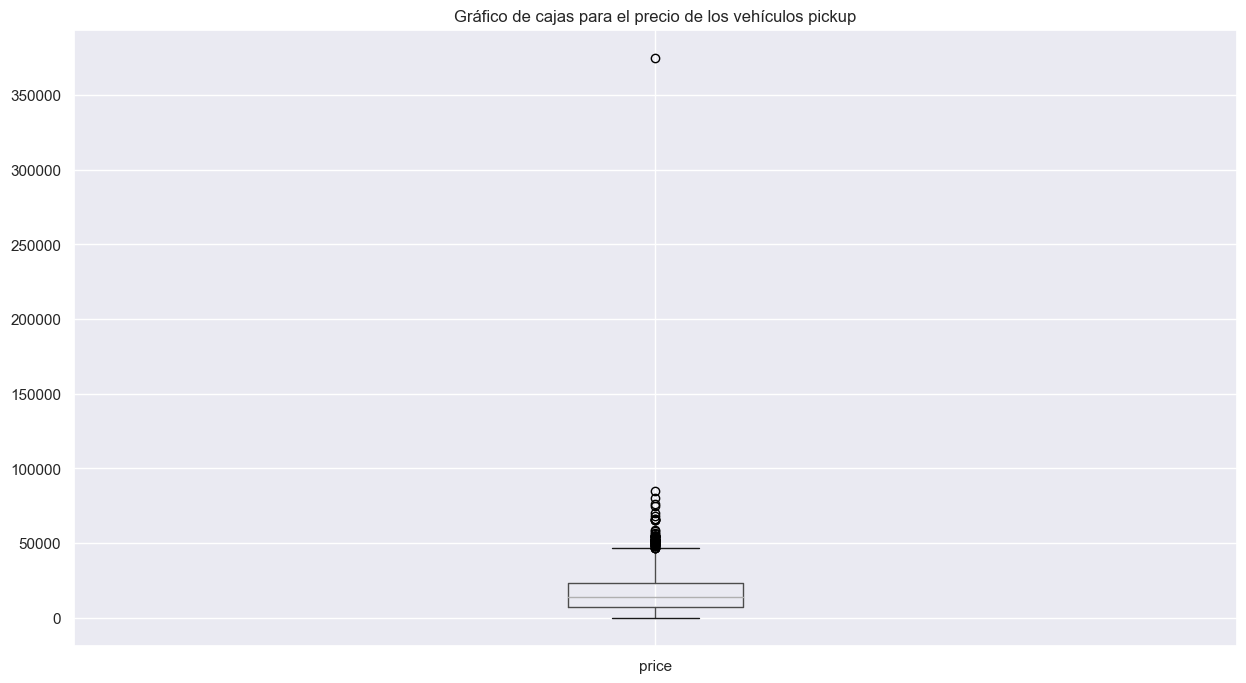

In [60]:
# Diagrama de cajas para el tipo de vehículo: pickup
df_vehicles_pick.boxplot('price').set(title='Gráfico de cajas para el precio de los vehículos pickup')

- Se asignará como límite superior 47000.

In [61]:
# Definición del límite superior para la variable 'price'
price_lim_sup = 47000

#### Determinación del límite inferior de la variable *'`price`'*

- Como vimos tanto en el *histograma* como en el *gráfico de cajas y bigotes*, el límite inferior es igual a cero. No obstante, no podemos considerar válido este valor pues no es un valor de venta.
- Analizaremos la cuarta parte inferior de los datos, es decir; los valores comprendidos entre el límite inferior y el primer cuartil para poder entender el comportamiento de esta variable en ese extremo.  

In [62]:
# Separamos la porción qie corresponde a los datos que queremos analizar
price_slice = df_vehicles.query('price <= price.quantile(0.25)')

array([[<Axes: title={'center': 'price'}>]], dtype=object)

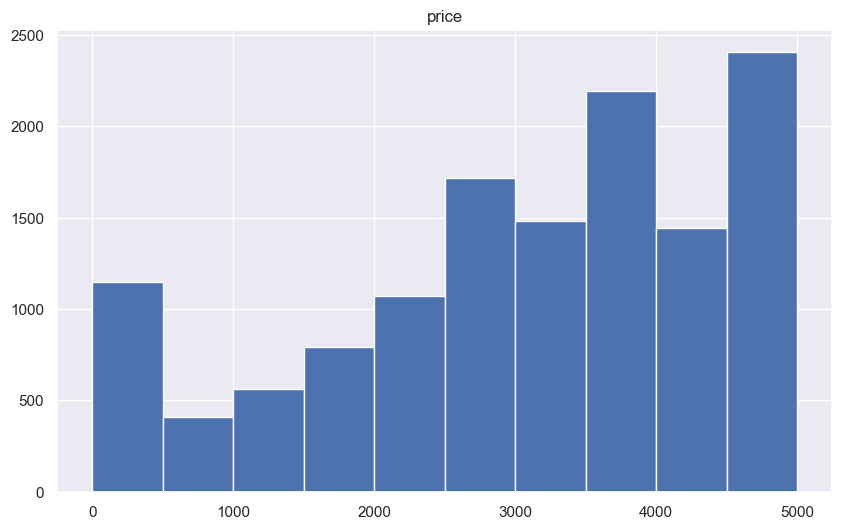

In [63]:
# Analizamos la distribución de los datos de esta porción con un histograma
price_slice.hist(column=['price'], figsize=(10,6), bins=10)

- Se elige 500 como límite inferior para *'`price`'*.

In [64]:
# Asegurando que el límite calculado pertenezca al conjunto de datos
price_slice = df_vehicles.query('500<= price <= @price_lim_sup')
price_lim_inf = np.min(price_slice['price'])
price_lim_inf

500



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. 
</div>


### Determinación de valores atípicos en la variable *'`years_of_vehicle`'*

#### Determinación del límite superior de la variable *'`years_of_vehicle`'*

In [65]:
# Calculo el límite superior utilizando el criterio de IQR
years_lim_sup = 2.5*df_vehicles['years_of_vehicle'].quantile(0.75)-1.5*df_vehicles['years_of_vehicle'].quantile(0.25)
years_lim_sup

24.0

- Ya habíamos determinado que el valor máximo admisible estaría entre 20 y 40 años pero si tomamos, de acuerdo con el criterio IQR, el valor calculado (24) estaríamos dejando por fuera el valor máximo admisible para el tipo *'convertible'* por lo que no sería adecuado utilizar sólo ese criterio.
- Se calculará el valor máximo admisible de esta categoría. 

In [66]:
# Calculo el límite superior utilizando el criterio de IQR
df_vehicles_conv = df_vehicles.query('type == "convertible"')
years_lim_sup = 2.5*df_vehicles_conv['years_of_vehicle'].quantile(0.75)-1.5*df_vehicles_conv['years_of_vehicle'].quantile(0.25)
years_lim_sup

41.0

Se tomará 41 como límite superior para este parámetro.

#### Determinación del límite inferior de la variable *'`years_of_vehicle`'*

- No se tiene inconveniente con que el límite inferior de esta variable sea cero pues bien pueden ser vehículos que se hayan vendido en mismo año de su fabricación.

In [67]:
years_lim_inf = 0

### Determinación de valores atípicos en la variable *'`odometer`'*

In [68]:
# Calculo el límite superior utilizando el criterio de IQR
# df_vehicles_pick = df_vehicles.query('type == "pickup"')
price_lim_sup = 2.5*df_vehicles_pick['odometer'].quantile(0.75)-1.5*df_vehicles_pick['odometer'].quantile(0.25)
price_lim_sup

297372.5

#### Determinación del límite superior de la variable *'`odometer`'*

In [69]:
# Calculo el límite superior utilizando el criterio de IQR
odom_lim_sup = 2.5*df_vehicles['odometer'].quantile(0.75)-1.5*df_vehicles['odometer'].quantile(0.25)
odom_lim_sup

271777.5

- Nuevamente, con la ayuda del gráfico de cajas por tipo de vehículo, hemos podido identificar que el tipo cuyo valor máximo admisible es el más alto es el *'pickup'*.
- Calcularemos este valor y lo tomaremos como límite superior.

In [70]:
# Calculo el límite superior utilizando el criterio de IQR
price_lim_sup = 2.5*df_vehicles_pick['odometer'].quantile(0.75)-1.5*df_vehicles_pick['odometer'].quantile(0.25)
price_lim_sup

297372.5

El límite superior para este parámetro se redondea a 298000 millas.

In [71]:
odom_lim_sup = 298000

#### Determinación del límite inferior de la variable *'`odometer`'*

- No se tiene inconveniente con que el límite inferior de esta variable sea cero pues bien pueden ser vehículos que se hayan vendido en mismo año de su fabricación.

In [72]:
# Asignación del límite inferior
odom_lim_inf = 0

### Determinación de valores atípicos en la variable *'`cylinders`'*

- Esta variables es categórica y no se encuentra ningún motivo como para restringir los valores que toma.

### Determinación de valores atípicos en la variable *'`condition_id`'*

- Esta variables es categórica y no se encuentra ningún motivo como para restringir los valores que toma.

In [73]:
# Almacena los datos sin valores atípicos en un DataFrame separado
df_vehicles_debugged= df_vehicles.query('@price_lim_inf <= price <= @price_lim_sup & @years_lim_inf <= years_of_vehicle <= @years_lim_sup & @odom_lim_inf <= odometer <= @odom_lim_sup')
df_vehicles_debugged

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,years_of_vehicle,annual_mileage,condition_id
0,9400,2011,bmw x5,good,6,gas,145000,automatic,SUV,black,True,2018-06-23,19,7,20714.285714,2
1,25500,2011,ford f150,good,6,gas,88705,automatic,pickup,white,True,2018-10-19,50,7,12672.142857,2
2,5500,2013,hyundai sonata,like new,4,gas,110000,automatic,sedan,red,False,2019-02-07,79,6,18333.333333,4
3,1500,2003,ford f150,fair,8,gas,161397,automatic,pickup,white,False,2019-03-22,9,16,10087.312500,1
4,14900,2017,chrysler 200,excellent,4,gas,80903,automatic,sedan,black,False,2019-04-02,28,2,40451.500000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51520,9249,2013,nissan maxima,like new,6,gas,88136,automatic,sedan,black,False,2018-10-03,37,5,17627.200000,4
51521,2700,2002,honda civic,salvage,4,gas,181500,automatic,sedan,white,False,2018-11-14,22,16,11343.750000,0
51522,3950,2009,hyundai sonata,excellent,4,gas,128000,automatic,sedan,blue,False,2018-11-15,32,9,14222.222222,3
51523,7455,2013,toyota corolla,good,4,gas,139573,automatic,sedan,black,False,2018-07-02,71,5,27914.600000,2


## Estudiar parámetros principales sin valores atípicos

### Comparación de histogramas

#### Parámetro **Precio**

Text(0.5, 0, 'Dólares')

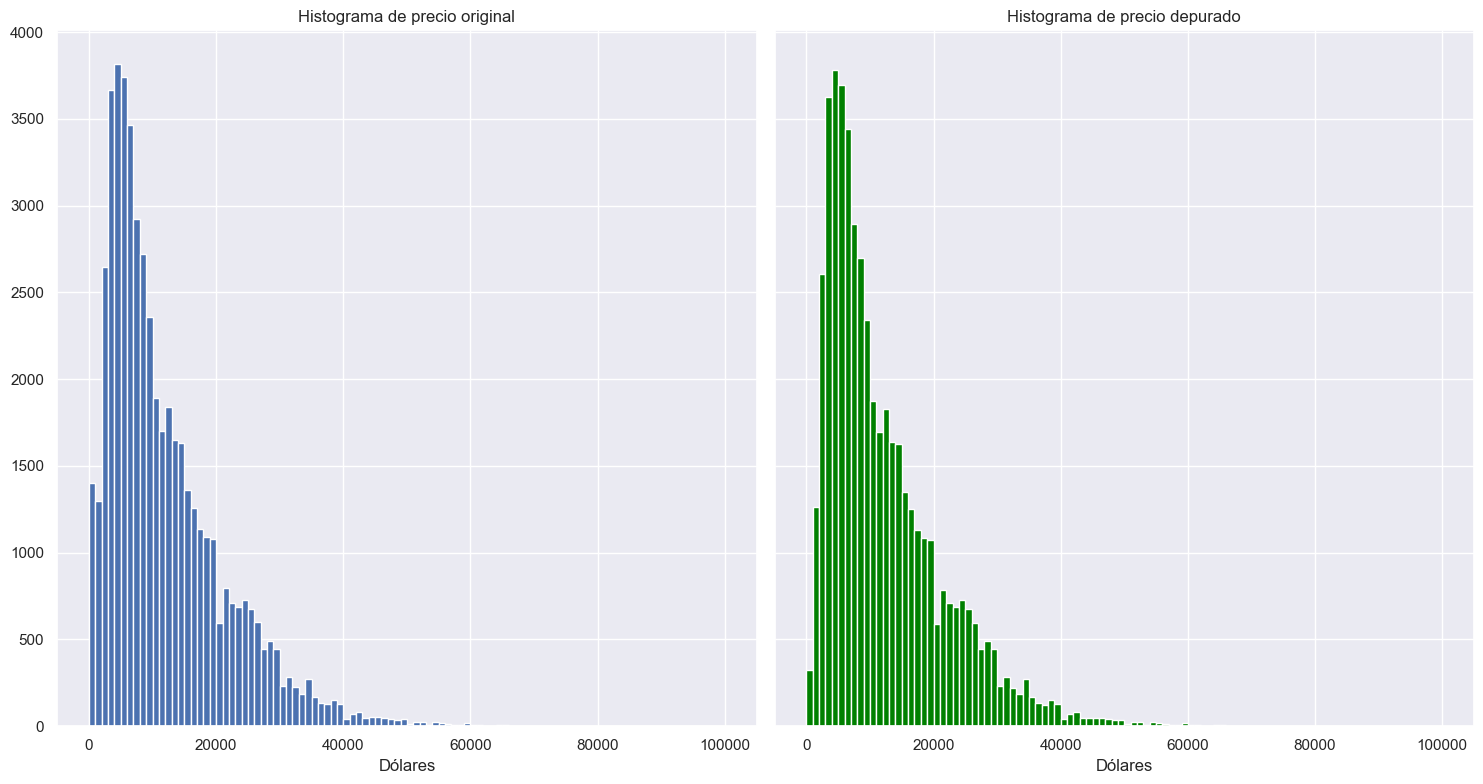

In [74]:
# Comparación de Histogramas.
price_original = df_vehicles['price']
price_debugged = df_vehicles_debugged['price']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(price_original, bins=100, range=(0,100000))
axs[0].set_title('Histograma de precio original')
axs[0].set_xlabel('Dólares')
axs[1].hist(price_debugged, bins=100, range=(0,100000), color='green')
axs[1].set_title('Histograma de precio depurado')
axs[1].set_xlabel('Dólares')

#### Parámetro **Años del vehículo**

Text(0.5, 0, 'Años')

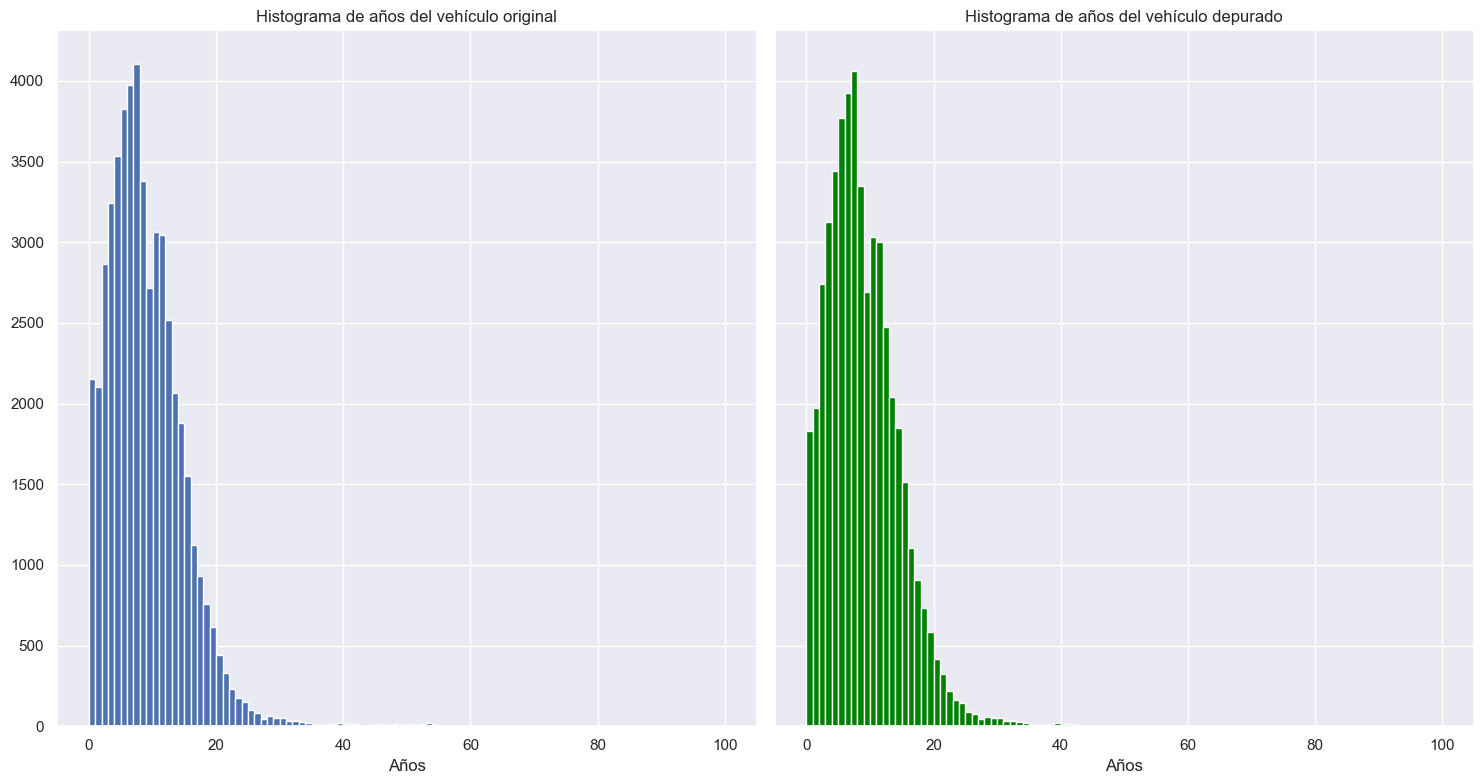

In [75]:
# Comparación de Histogramas.
years_original = df_vehicles['years_of_vehicle']
years_debugged = df_vehicles_debugged['years_of_vehicle']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(years_original, bins=100, range=(0,100))
axs[0].set_title('Histograma de años del vehículo original')
axs[0].set_xlabel('Años')
axs[1].hist(years_debugged, bins=100, range=(0,100), color='green')
axs[1].set_title('Histograma de años del vehículo depurado')
axs[1].set_xlabel('Años')

#### Parámetro **Millaje**

Text(0.5, 0, 'Años')

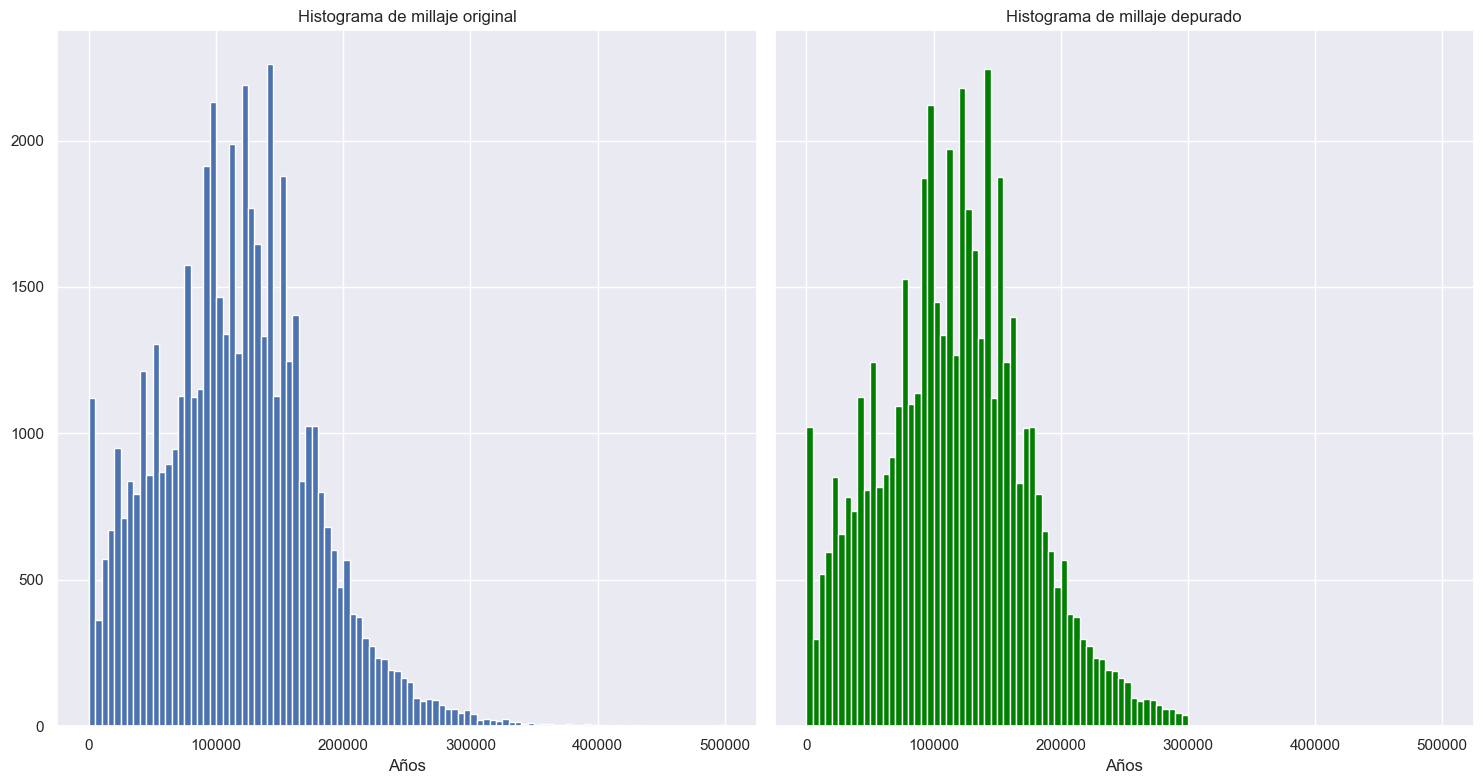

In [76]:
# Comparación de Histogramas.
miles_original = df_vehicles['odometer']
miles_debugged = df_vehicles_debugged['odometer']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(miles_original, bins=100, range=(0,500000))
axs[0].set_title('Histograma de millaje original')
axs[0].set_xlabel('Años')
axs[1].hist(miles_debugged, bins=100, range=(0,500000), color='green')
axs[1].set_title('Histograma de millaje depurado')
axs[1].set_xlabel('Años')

#### Parámetro **Cilindraje**

Text(0.5, 0, 'Cilindros')

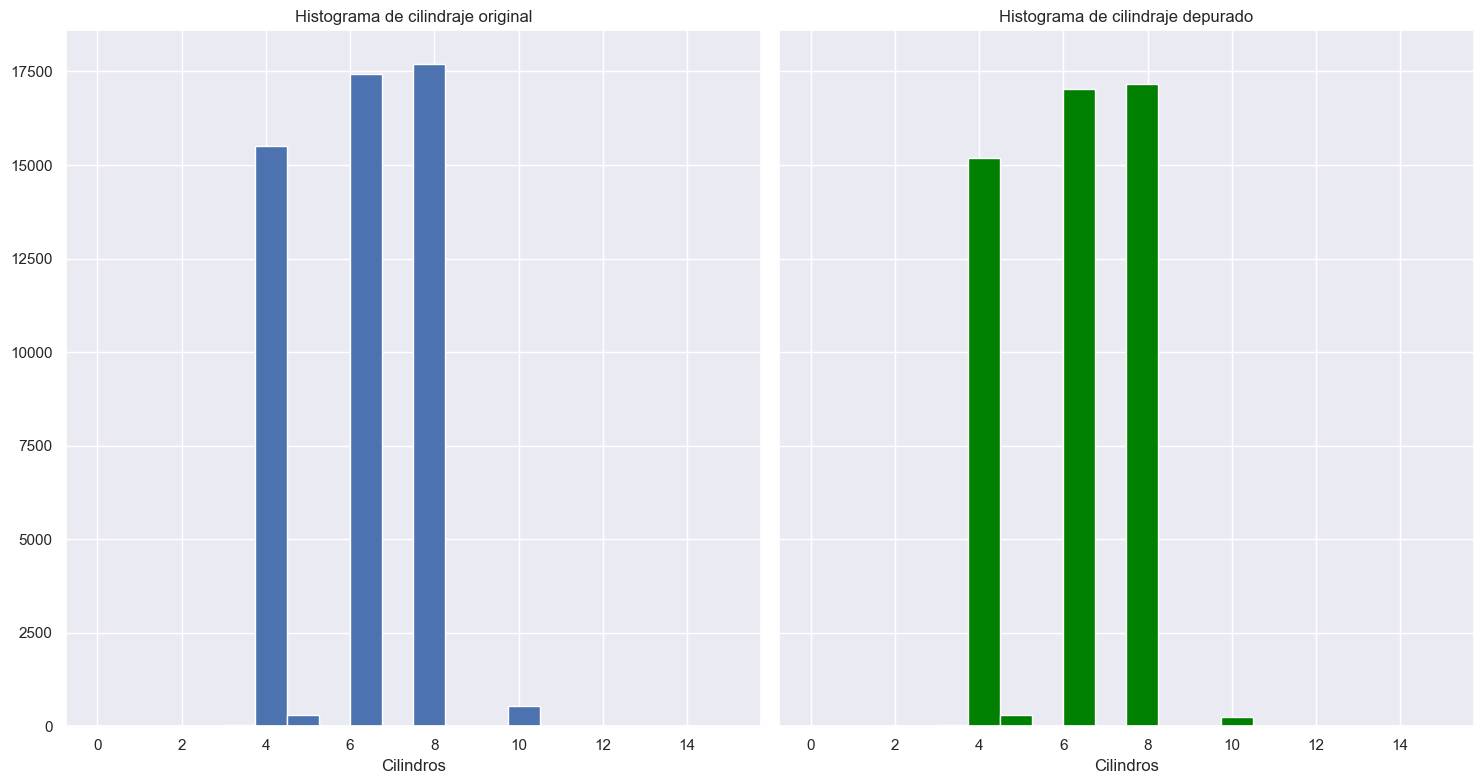

In [77]:
# Comparación de Histogramas.
cylin_original = df_vehicles['cylinders']
cylin_debugged = df_vehicles_debugged['cylinders']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(cylin_original, bins=20, range=(0,15))
axs[0].set_title('Histograma de cilindraje original')
axs[0].set_xlabel('Cilindros')
axs[1].hist(cylin_debugged, bins=20, range=(0,15), color='green')
axs[1].set_title('Histograma de cilindraje depurado')
axs[1].set_xlabel('Cilindros')

#### Parámetro **Estado**

Text(0.5, 0, 'Condición')

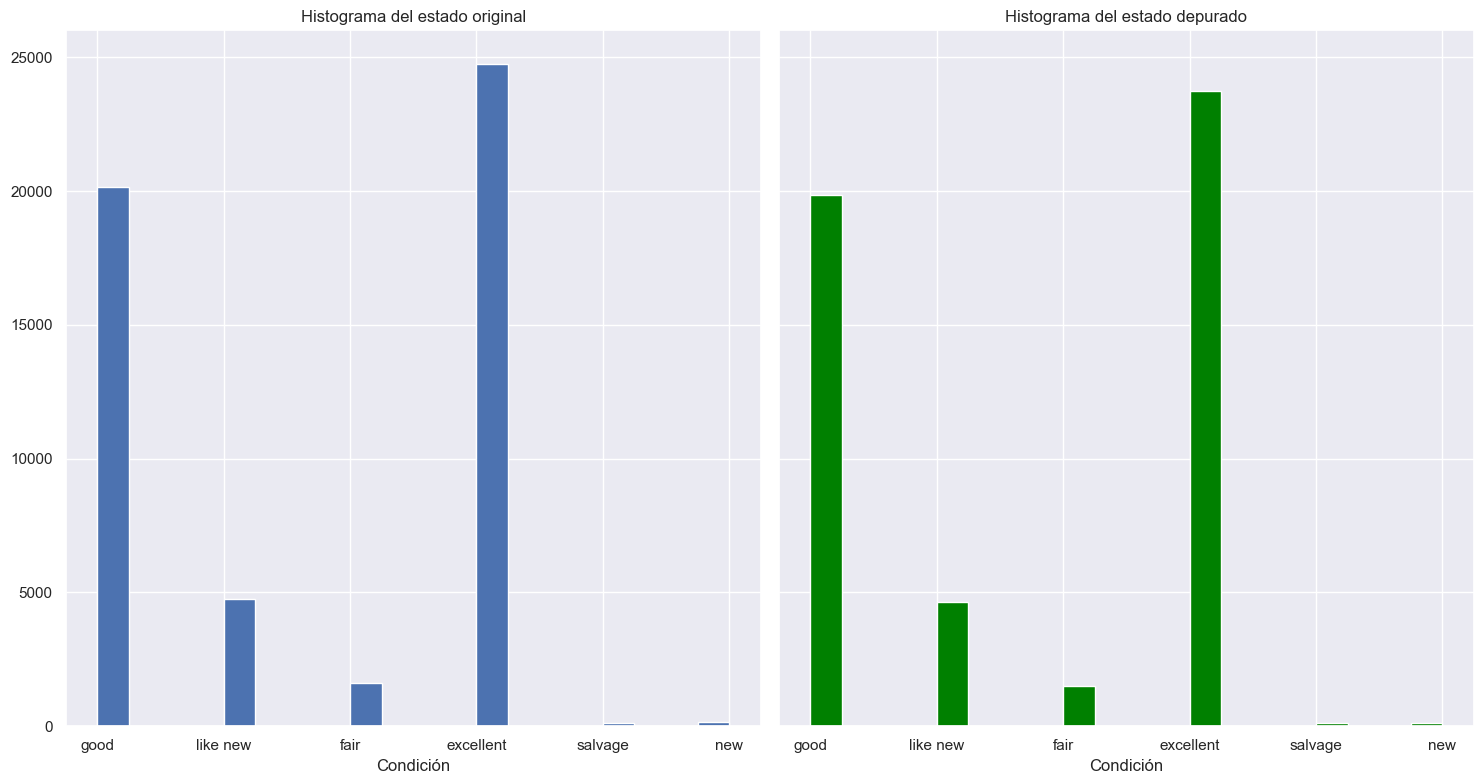

In [78]:
# Comparación de Histogramas.
cond_original = df_vehicles['condition']
cond_debugged = df_vehicles_debugged['condition']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(cond_original, bins=20)
axs[0].set_title('Histograma del estado original')
axs[0].set_xlabel('Condición')
axs[1].hist(cond_debugged, bins=20, color='green')
axs[1].set_title('Histograma del estado depurado')
axs[1].set_xlabel('Condición')

- De la comparación de histogramas de las variables cuantitativas se puede concluir que, se han conservado aquellos valores con frecuencias más altas obteniendo un histograma depurado bastante parecido al original obviando las colas de atípicos.
- De la comparación de histogramas de las variables categóricas, se concluye que la proporción de cada categporía se ha conservado, sin embargo, si se experimenta una reducción proporcional en las frecuencias. Esto es explicable porque al haber menos datos estos se reflejan en las variables categóricas.

## Periodo de colocación de los anuncios

Analizaremos el tiempo en que demoran en venderse los vehículos desde la página web en función de los parámetros establecidos: precio, años del vehículo, millaje, cilinrdraje y etsado.

Text(0.5, 0, 'Días')

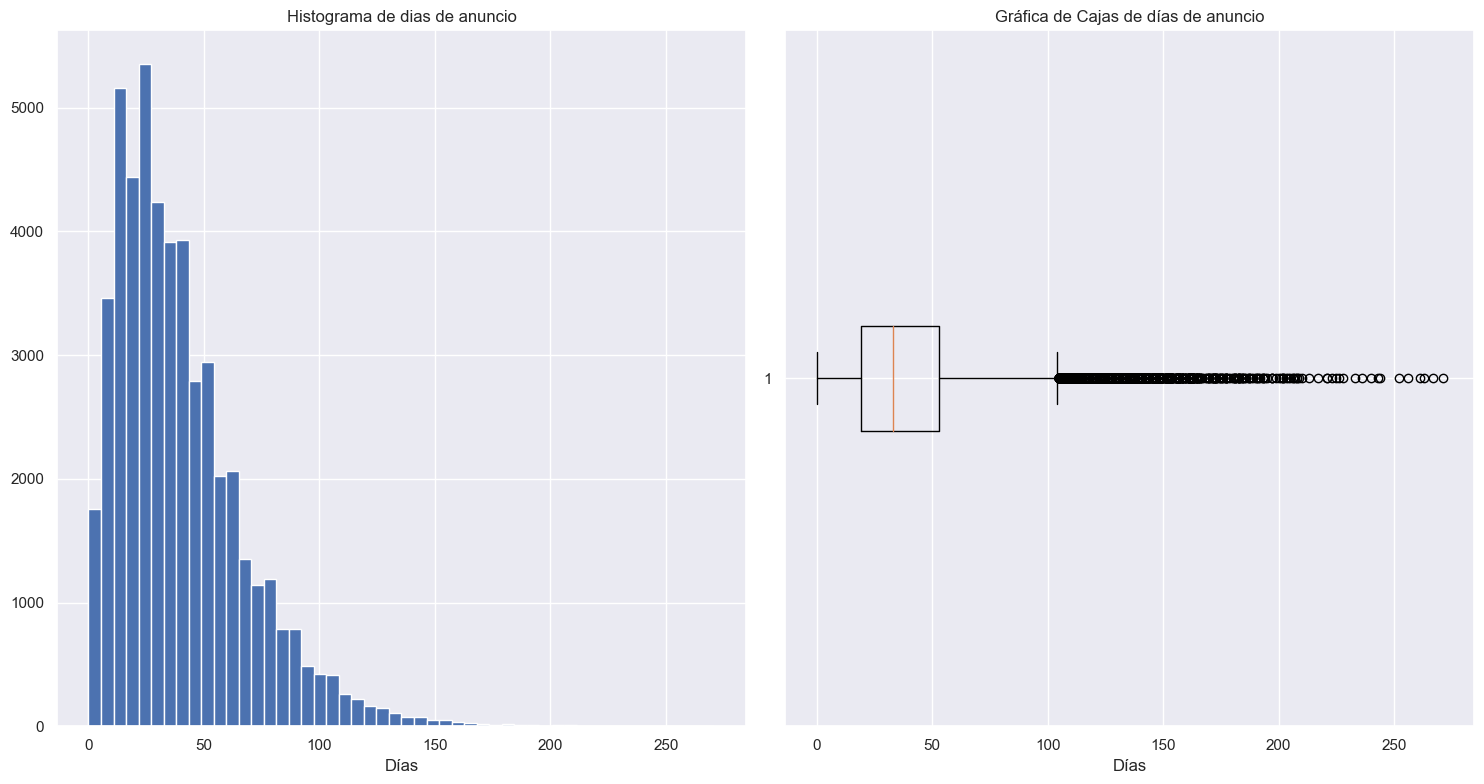

In [79]:
# Histograma y gráfica de cajas del parámetro 'days_listed'.
days = df_vehicles_debugged['days_listed']

fig, axs = plt.subplots(1, 2, tight_layout=True)

axs[0].hist(days, bins=50)
axs[0].set_title('Histograma de dias de anuncio')
axs[0].set_xlabel('Días')
axs[1].boxplot(days, vert=False)
axs[1].set_title('Gráfica de Cajas de días de anuncio')
axs[1].set_xlabel('Días')

In [80]:
# Calculando la media y mediana
df_vehicles_debugged['days_listed'].agg(['mean','median'])

mean      39.556367
median    33.000000
Name: days_listed, dtype: float64

La media y la mediana están relativamente cerca.

In [81]:
df_vehicles_debugged['days_listed'].describe()

count    49985.000000
mean        39.556367
std         28.217063
min          0.000000
25%         19.000000
50%         33.000000
75%         53.000000
max        271.000000
Name: days_listed, dtype: float64

In [82]:
# Calculo el límite superior utilizando el criterio de IQR
days_lim_sup = 2.5*df_vehicles_debugged['days_listed'].quantile(0.75)-1.5*df_vehicles_debugged['days_listed'].quantile(0.25)
days_lim_sup

104.0

- El periodo de colocación habitual de un anuncio se encuentra entre 19 y 33 días ya que en ese segmento existe una mayor concentración de datos.
- Se considera que los anuncios que se eliminan rápidamente son aquellos que se ubican entre 0 y 19 días.
- Los anuncios que fueron publicados por un tiempo extremadamente largo son aquellos que excedieron los 104 días.

### Características de los anuncios que se eliminan rápidamente

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'years_of_vehicle'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'cylinders'}>],
       [<Axes: title={'center': 'condition_id'}>, <Axes: >]], dtype=object)

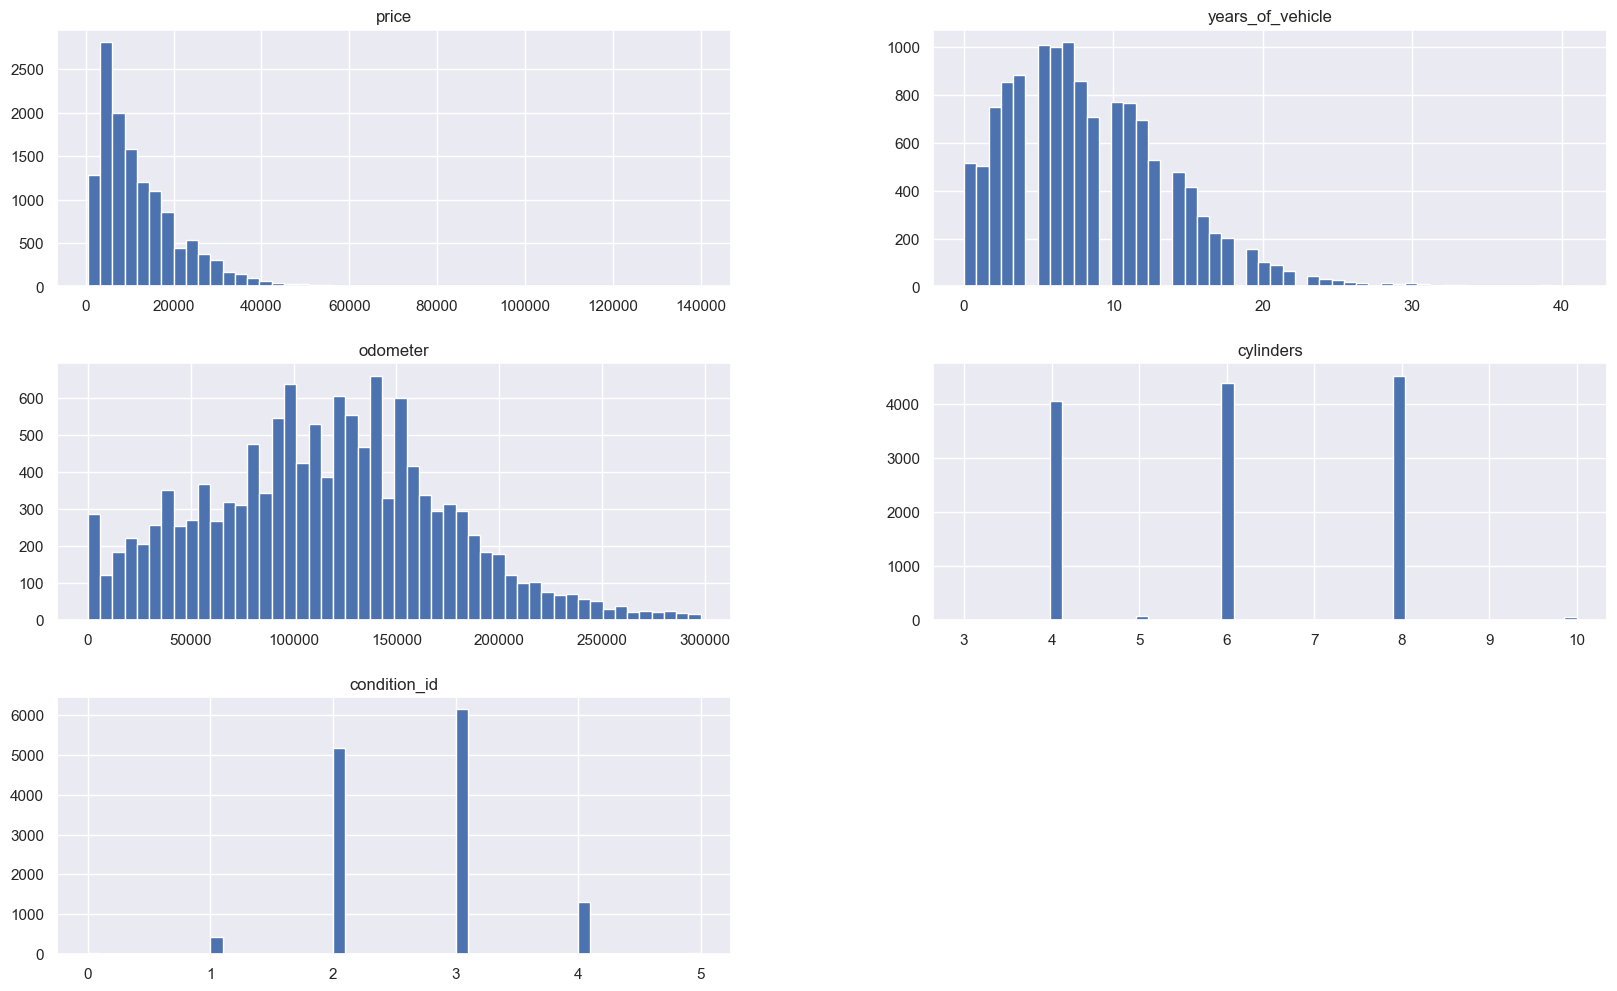

In [83]:
# Slice de anuncios que se eliminaron mas rapido.
days_listed_fast = df_vehicles_debugged.query('days_listed <= 19')

days_listed_fast.hist(column=['price', 'years_of_vehicle','odometer', 'cylinders','condition_id'], figsize=(20,12), bins=50)

### Características de los anuncios publicados por un tiempo extremadamente largo

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'years_of_vehicle'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'cylinders'}>],
       [<Axes: title={'center': 'condition_id'}>, <Axes: >]], dtype=object)

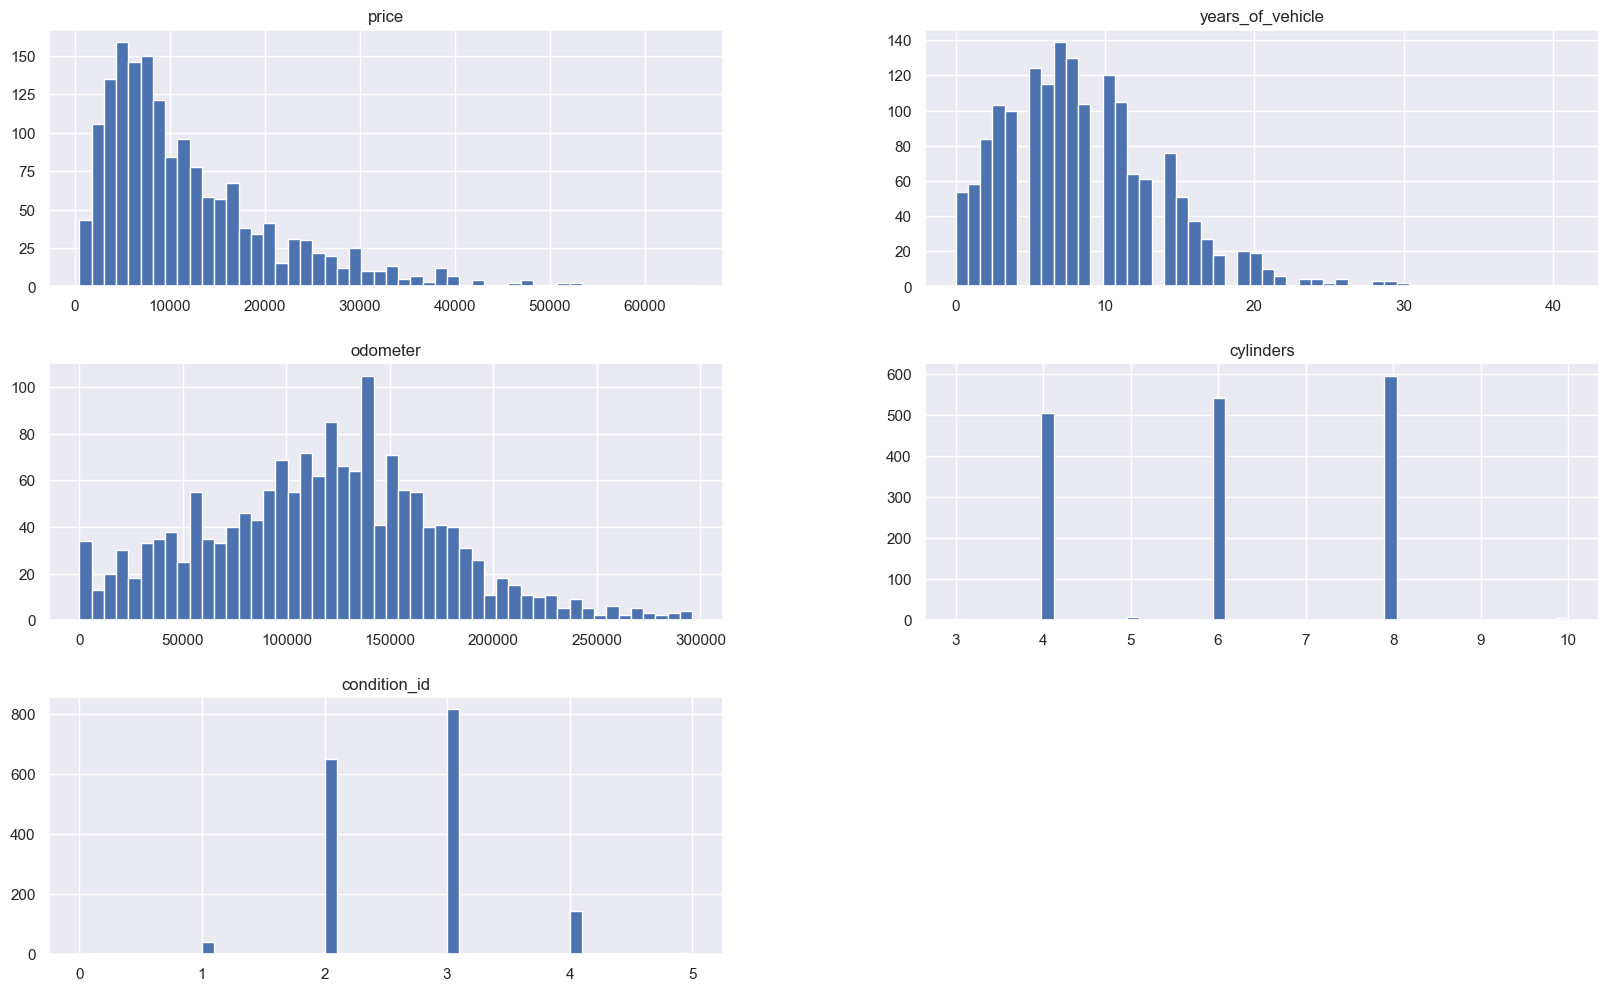

In [84]:
# Slice de anuncios publicados por un tiempo extremadamente largo.
days_listed_slow = df_vehicles_debugged.query('days_listed >= 104')

days_listed_slow.hist(column=['price', 'years_of_vehicle','odometer', 'cylinders','condition_id'], figsize=(20,12), bins=50)

Las gráficas mostradas dificultan la comparación. Por esta razón compararemos las varibles de manera independiente.

### Comparación de las características entre los anuncios eliminados rápidamente y los que estuvieron publicados por un tiempo extremadamente largo.

#### Parámetro **Precio**

Text(0.5, 0, 'Dólares')

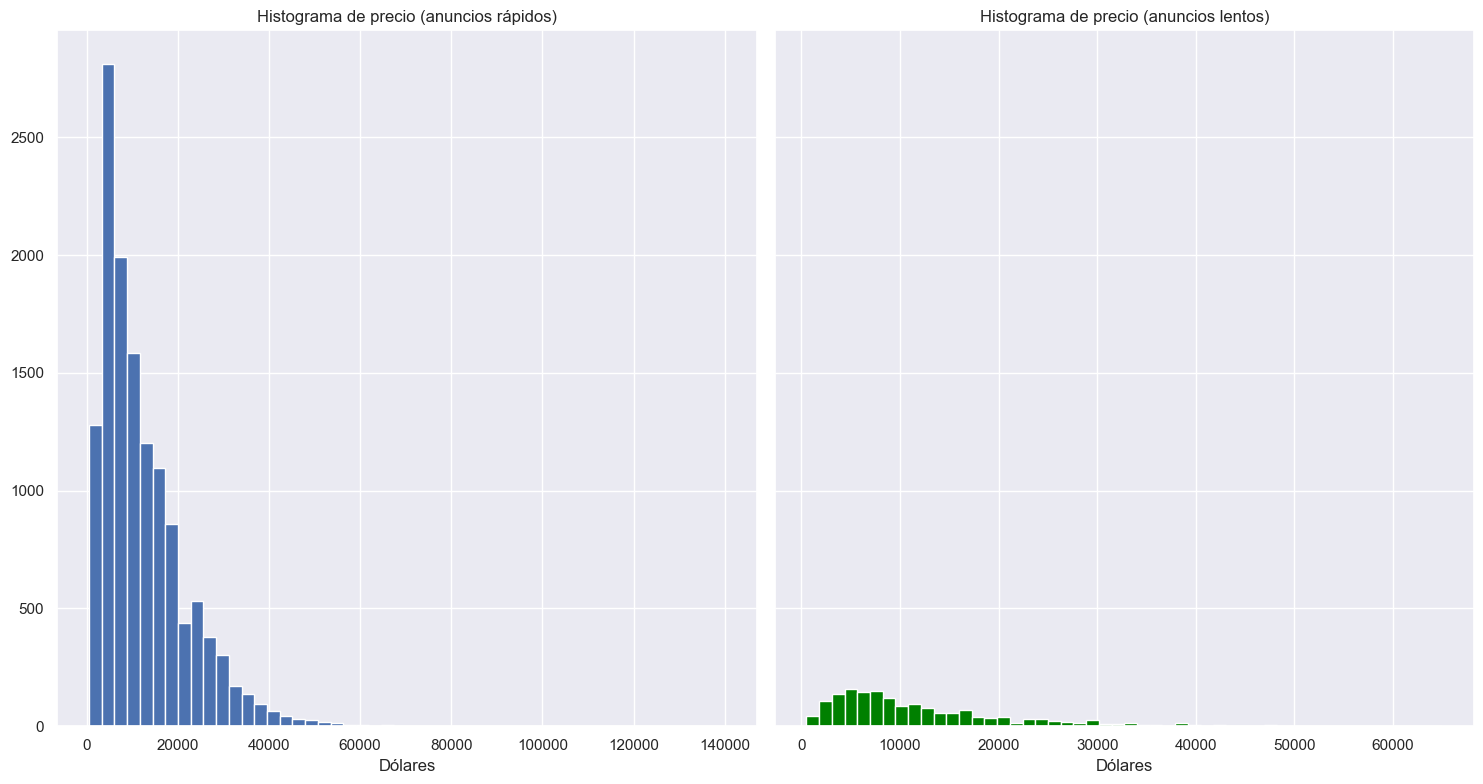

In [85]:
# Comparación de Histogramas.
price_fast = days_listed_fast['price']
price_slow = days_listed_slow['price']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(price_fast, bins=50)
axs[0].set_title('Histograma de precio (anuncios rápidos)')
axs[0].set_xlabel('Dólares')
axs[1].hist(price_slow, bins=50, color='green')
axs[1].set_title('Histograma de precio (anuncios lentos)')
axs[1].set_xlabel('Dólares')

#### Parámetro **Años del vehículo**

Text(0.5, 0, 'Años')

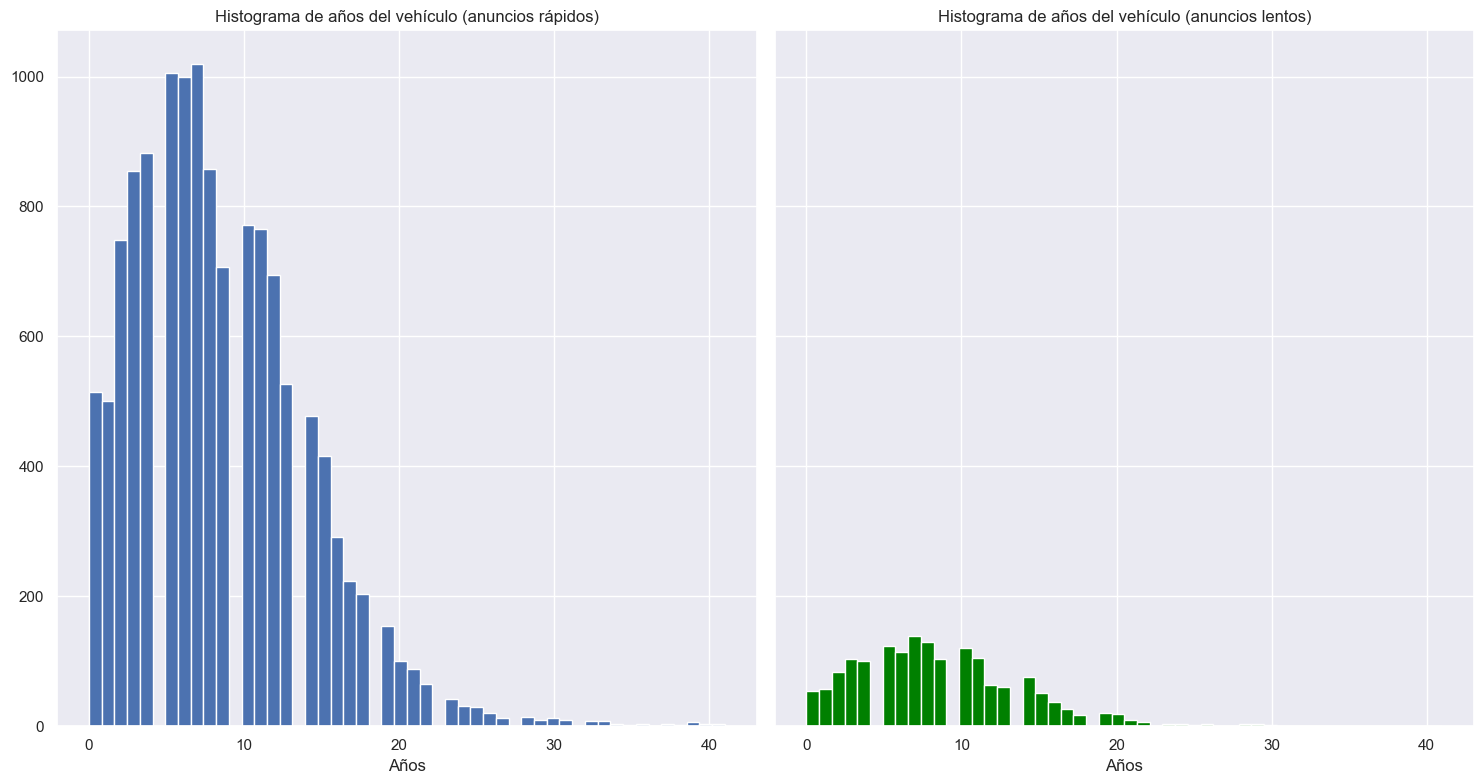

In [86]:
# Comparación de Histogramas.
years_fast = days_listed_fast['years_of_vehicle']
years_slow = days_listed_slow['years_of_vehicle']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(years_fast, bins=50)
axs[0].set_title('Histograma de años del vehículo (anuncios rápidos)')
axs[0].set_xlabel('Años')
axs[1].hist(years_slow, bins=50, color='green')
axs[1].set_title('Histograma de años del vehículo (anuncios lentos)')
axs[1].set_xlabel('Años')

#### Parámetro **Millaje**

Text(0.5, 0, 'Millas')

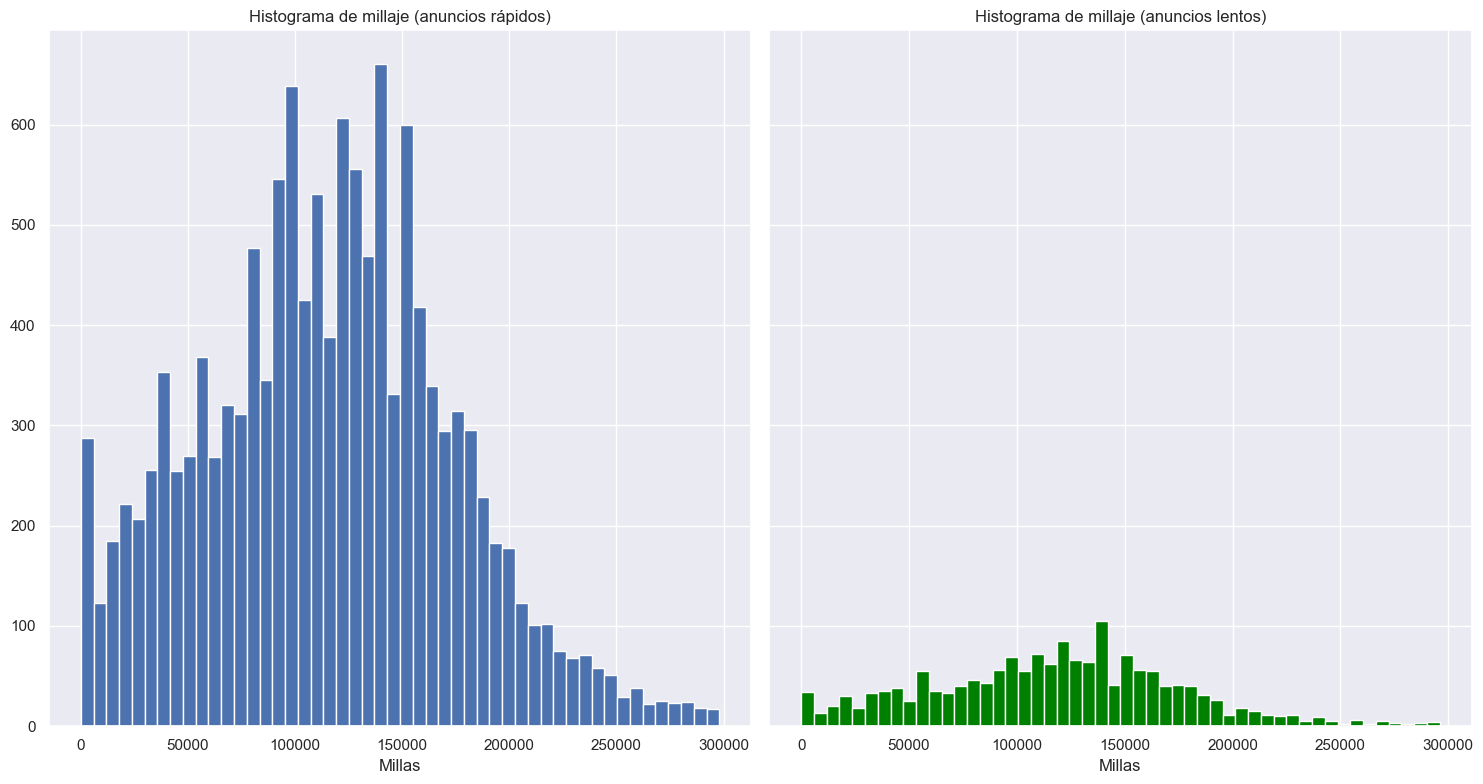

In [87]:
# Comparación de Histogramas.
miles_fast = days_listed_fast['odometer']
miles_slow = days_listed_slow['odometer']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(miles_fast, bins=50)
axs[0].set_title('Histograma de millaje (anuncios rápidos)')
axs[0].set_xlabel('Millas')
axs[1].hist(miles_slow, bins=50, color='green')
axs[1].set_title('Histograma de millaje (anuncios lentos)')
axs[1].set_xlabel('Millas')

#### Parámetro **Cilindraje**

Text(0.5, 0, 'Cilindros')

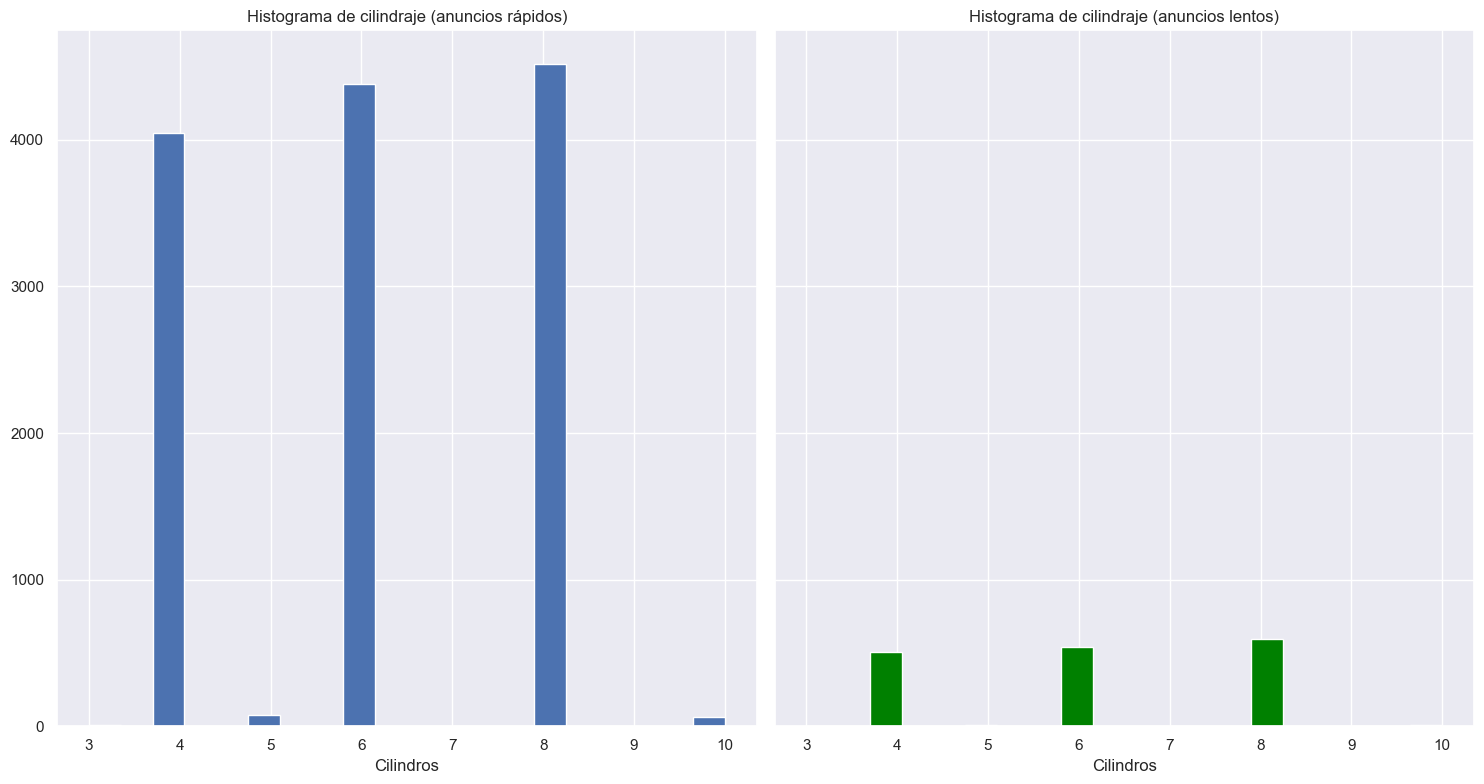

In [88]:
# Comparación de Histogramas.
cylind_fast = days_listed_fast['cylinders']
cylind_slow = days_listed_slow['cylinders']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(cylind_fast, bins=20)
axs[0].set_title('Histograma de cilindraje (anuncios rápidos)')
axs[0].set_xlabel('Cilindros')
axs[1].hist(cylind_slow, bins=20, color='green')
axs[1].set_title('Histograma de cilindraje (anuncios lentos)')
axs[1].set_xlabel('Cilindros')

#### Parámetro **Estado**

Text(0.5, 0, 'Condition')

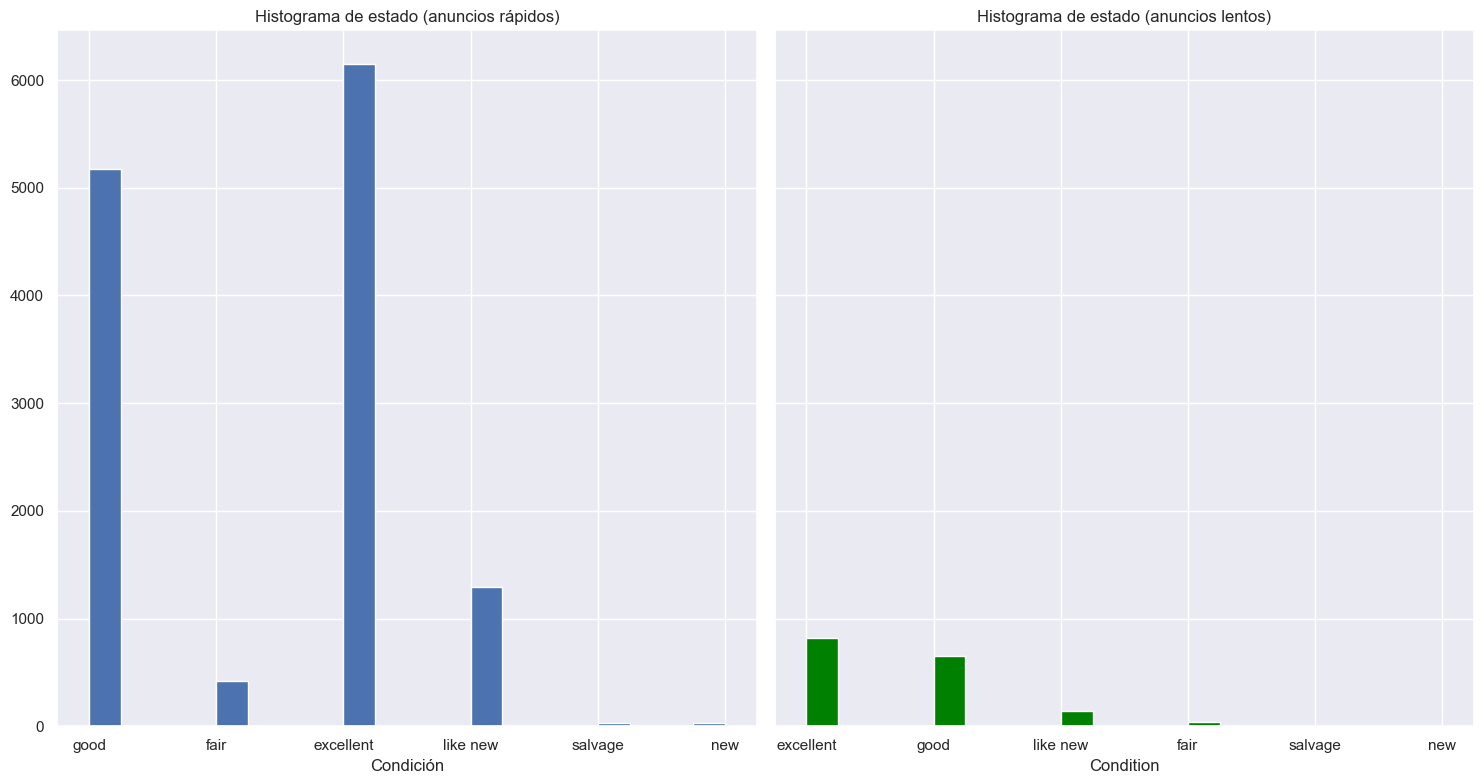

In [89]:
# Comparación de Histogramas.
condition_fast = days_listed_fast['condition']
condition_slow = days_listed_slow['condition']

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(condition_fast, bins=20)
axs[0].set_title('Histograma de estado (anuncios rápidos)')
axs[0].set_xlabel('Condición')
axs[1].hist(condition_slow, bins=20, color='green')
axs[1].set_title('Histograma de estado (anuncios lentos)')
axs[1].set_xlabel('Condition')

Hasta este punto, no se ha encontrado ningún patrón que puda explicar porqué un grupo de de vehículos tardó más en ser vendido. Lo que sí es evidente es que la cantidad de vehículos que demoraron en venderse es mucho menor que la cantidad de vehículos que se vendió rápidamente.

## Precio promedio por cada tipo de vehículo

Se analizará el número de anuncios y el precio promedio para cada tipo de vehículo. Se trazará gráficos mostrando la dependencia de la cantidad de anuncios en cada tipo de vehículo. 

Se seleccionará los dos tipos de vehículos **top** en cada punto de nuestra evaluación.

In [90]:
# Número de anuncios por tipo de vehículo
days_by_type = df_vehicles_debugged.groupby('type')['days_listed'].sum().sort_values(ascending=False)
days_by_type

type
SUV            479860
truck          469447
sedan          466075
pickup         270223
coupe           83595
wagon           61507
mini-van        45603
hatchback       41289
van             24848
convertible     15800
other            9531
offroad          8403
bus              1044
Name: days_listed, dtype: int64

<Axes: title={'center': 'Cantidad de anuncios por tipo de vehículo'}, xlabel='type', ylabel='Días'>

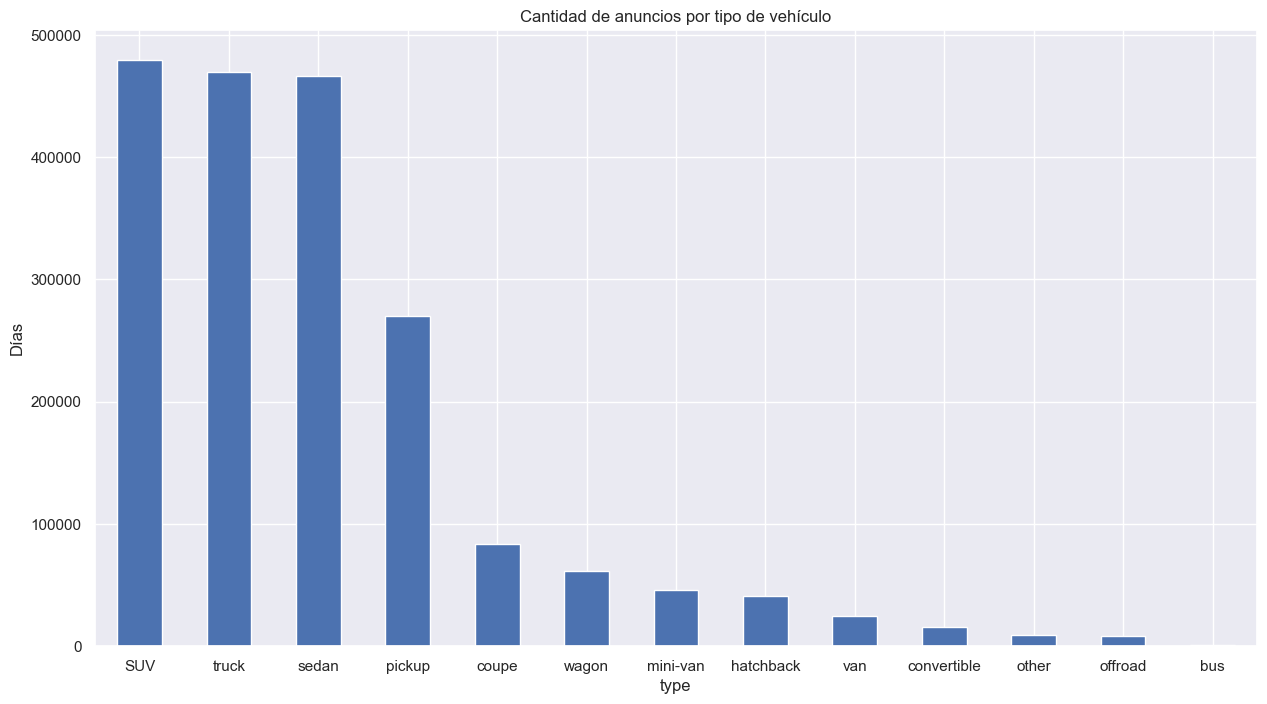

In [91]:
# Gráfico de la dependencia de días de anuncios por tipo de vehículo
days_by_type.plot.bar(rot=0, ylabel='Días', title='Cantidad de anuncios por tipo de vehículo')

Los dos tipos de vehículos con mayores precios son: *'SUV'* y *'truck'*. Se observa una diferencia significativa entre los primeros cuatro tipos de vehículos y los demás. Esto puede deberse a que se tuvieron mayor cantidad de unidades de esos tipos en el parque. Será necesario revisar los valores promedio para poder concluir en algo. Esto lo revisaremos luego.  

In [92]:
# Precio promedio por tipo de vehículo
price_by_type = df_vehicles_debugged.groupby('type')['price'].mean().sort_values(ascending=False)
price_by_type

type
truck          17257.215728
bus            17135.666667
pickup         16159.055652
coupe          14588.954951
offroad        14528.671429
convertible    13803.544118
SUV            11453.585869
van            10940.045977
other          10798.270916
wagon           9192.770449
mini-van        8220.161905
sedan           7125.105072
hatchback       7020.165686
Name: price, dtype: float64

<Axes: title={'center': 'Precio promedio por tipo de vehículo'}, xlabel='type', ylabel='Dólares'>

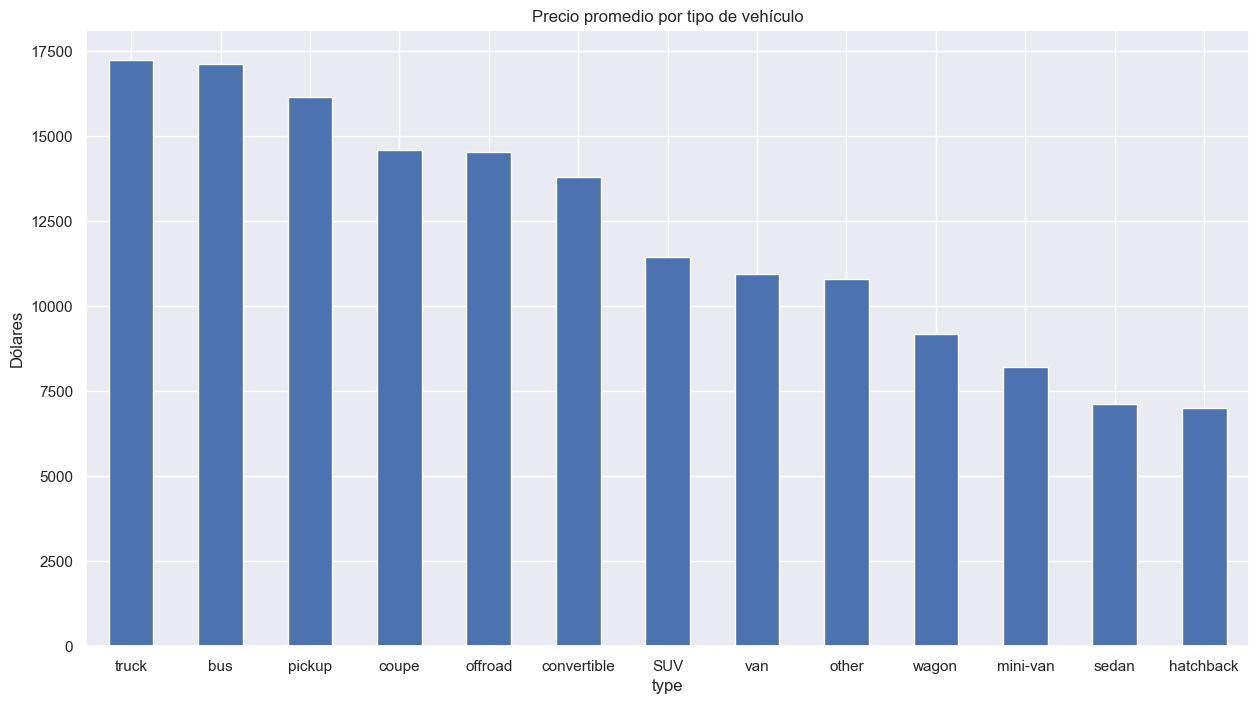

In [93]:
# Gráfico de la dependencia de días de anuncios por tipo de vehículo
price_by_type.plot.bar(rot=0, ylabel='Dólares', title='Precio promedio por tipo de vehículo')

Los dos tipos de vehículos con mayores precios son: *'truck'* y *'bus'*.

Ahora revisaremos si el precio tiene alguna relación de dependencia con la cantidad de días de anuncios. 

In [94]:
# Número de anuncios y precio promedio por tipo de vehículo
days_price_by_type = pd.merge(days_by_type, price_by_type, on = 'type', how = "inner")
days_price_by_type

,days_listed,price
type,,
SUV,479860,11453.585869
truck,469447,17257.215728
sedan,466075,7125.105072
pickup,270223,16159.055652
coupe,83595,14588.954951
wagon,61507,9192.770449
mini-van,45603,8220.161905
hatchback,41289,7020.165686
van,24848,10940.045977


In [95]:
days_price_by_type['price'] = days_price_by_type['price'].astype('int')

In [96]:
days_price_by_type

,days_listed,price
type,,
SUV,479860,11453
truck,469447,17257
sedan,466075,7125
pickup,270223,16159
coupe,83595,14588
wagon,61507,9192
mini-van,45603,8220
hatchback,41289,7020
van,24848,10940


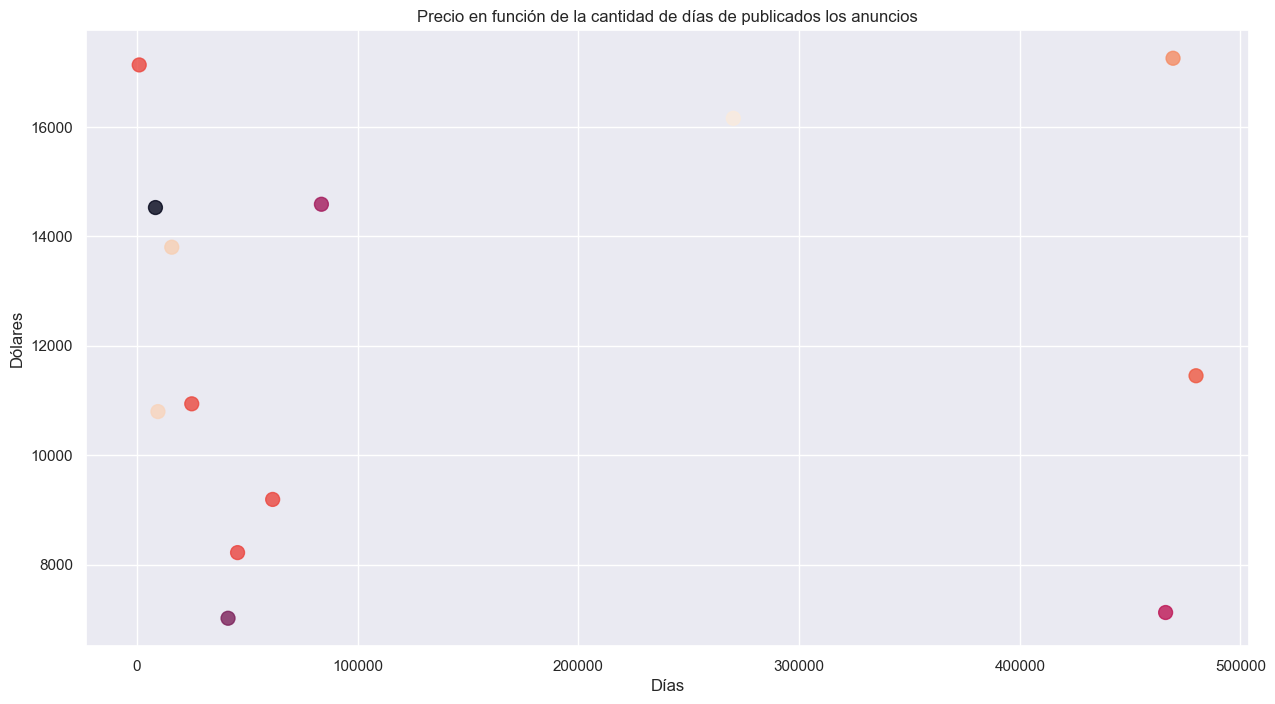

In [97]:
# Dependencia del precio en función de los días de publicación de los anuncios por tipo de vehículo
N = 13
x_1 = days_price_by_type['days_listed']
y_1 = days_price_by_type['price']
colors = np.random.rand(N)

plt.scatter(x_1, y_1, s=100, c=colors, alpha=0.8)
plt.xlabel('Días')
plt.ylabel('Dólares')
plt.title('Precio en función de la cantidad de días de publicados los anuncios')
plt.show()

No existe una relación entre los días de publicación de anuncios con el precio de los vehículos.

In [98]:
# Revisemos el comportamiento de la cantidad de días promedio por tipo de vehículo
mean_days_listed_by_type = df_vehicles_debugged.groupby('type')['days_listed'].mean().sort_values(ascending=False)
mean_days_listed_by_type

type
bus            43.500000
van            40.801314
wagon          40.571900
hatchback      40.479412
offroad        40.014286
SUV            39.792686
mini-van       39.483117
truck          39.482506
sedan          39.397718
pickup         39.265185
coupe          39.228062
convertible    38.725490
other          37.972112
Name: days_listed, dtype: float64

<Axes: title={'center': 'Cantidad de días de anuncios promedio por tipo de vehículo'}, xlabel='type', ylabel='Días'>

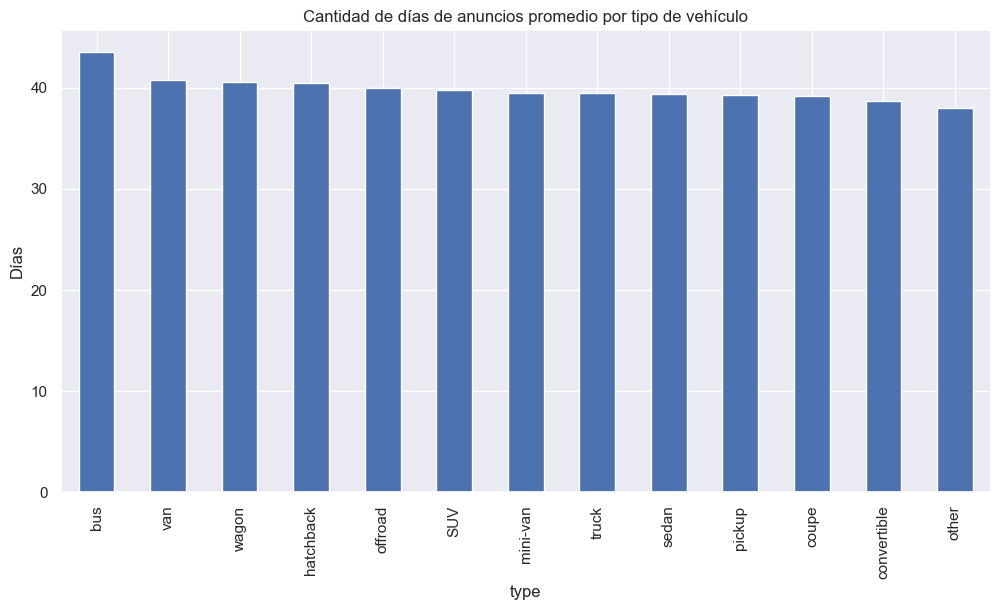

In [99]:
mean_days_listed_by_type.plot.bar(ylabel='Días', title='Cantidad de días de anuncios promedio por tipo de vehículo', figsize=(12,6))

Podemos observar que la cantidad de días de anuncios promedio por tipo de vehículo es bastante pareja. Aún así, por muy poco, se puede distinguir que los dos tipos de vehículos con mayor cantidad de días de anuncios promedio son: *'bus'* y *'van'*.

## Factores de precio

- Evaluaremos los factores que impactan más sobre el precio de los vehículos. 
- Los tipos de vehículos más populares son *'SUV'* y *'truck'*. Para estos tipos de vehículos se estudiará si el precio depende de la edad, el millaje, la condición, el tipo de transmisión o el color. 
- Las variables categóricas (tipo de transmisión y color) serán analizadas mediante gráficos de caja y bigotes y para el resto se empleará un análisis por medio de gráficos de dispersión. 

### Análisis de las variables numéricas

In [100]:
# Solo se tomará en cuenta los dos tipos con más anuncios detectados
df_vehicles_corr = df_vehicles_debugged.query('type in ("SUV","truck")')
df_vehicles_corr = df_vehicles_corr.drop(['model_year', 'model', 'cylinders', 'fuel', 'is_4wd', 'date_posted', 'annual_mileage', 'condition'], axis=1)
df_vehicles_corr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23949 entries, 0 to 51516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             23949 non-null  int64 
 1   odometer          23949 non-null  int32 
 2   transmission      23949 non-null  object
 3   type              23949 non-null  object
 4   paint_color       23949 non-null  object
 5   days_listed       23949 non-null  int64 
 6   years_of_vehicle  23949 non-null  int64 
 7   condition_id      23949 non-null  int64 
dtypes: int32(1), int64(4), object(3)
memory usage: 1.6+ MB


In [101]:
# Obteniendo la matriz de correlación
df_vehicles_corr.corr()

C:\Users\jorge\AppData\Local\Temp\ipykernel_31436\1969321472.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_vehicles_corr.corr()


,price,odometer,days_listed,years_of_vehicle,condition_id
price,1.000000,-0.537532,-0.005451,-0.594241,0.286296
odometer,-0.537532,1.000000,0.005345,0.573773,-0.319768
days_listed,-0.005451,0.005345,1.000000,0.011757,-0.004206
years_of_vehicle,-0.594241,0.573773,0.011757,1.000000,-0.325850
condition_id,0.286296,-0.319768,-0.004206,-0.325850,1.000000




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien incluir la correlación. Sin embargo, para la variable condición, quizá lo mejor sea utilizar una prueba de hipotésis. 
</div>


array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='odometer', ylabel='price'>,
        <Axes: xlabel='days_listed', ylabel='price'>,
        <Axes: xlabel='years_of_vehicle', ylabel='price'>,
        <Axes: xlabel='condition_id', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='odometer'>,
        <Axes: xlabel='odometer', ylabel='odometer'>,
        <Axes: xlabel='days_listed', ylabel='odometer'>,
        <Axes: xlabel='years_of_vehicle', ylabel='odometer'>,
        <Axes: xlabel='condition_id', ylabel='odometer'>],
       [<Axes: xlabel='price', ylabel='days_listed'>,
        <Axes: xlabel='odometer', ylabel='days_listed'>,
        <Axes: xlabel='days_listed', ylabel='days_listed'>,
        <Axes: xlabel='years_of_vehicle', ylabel='days_listed'>,
        <Axes: xlabel='condition_id', ylabel='days_listed'>],
       [<Axes: xlabel='price', ylabel='years_of_vehicle'>,
        <Axes: xlabel='odometer', ylabel='years_of_vehicle'>,
        <Axes: xlabel='days_li

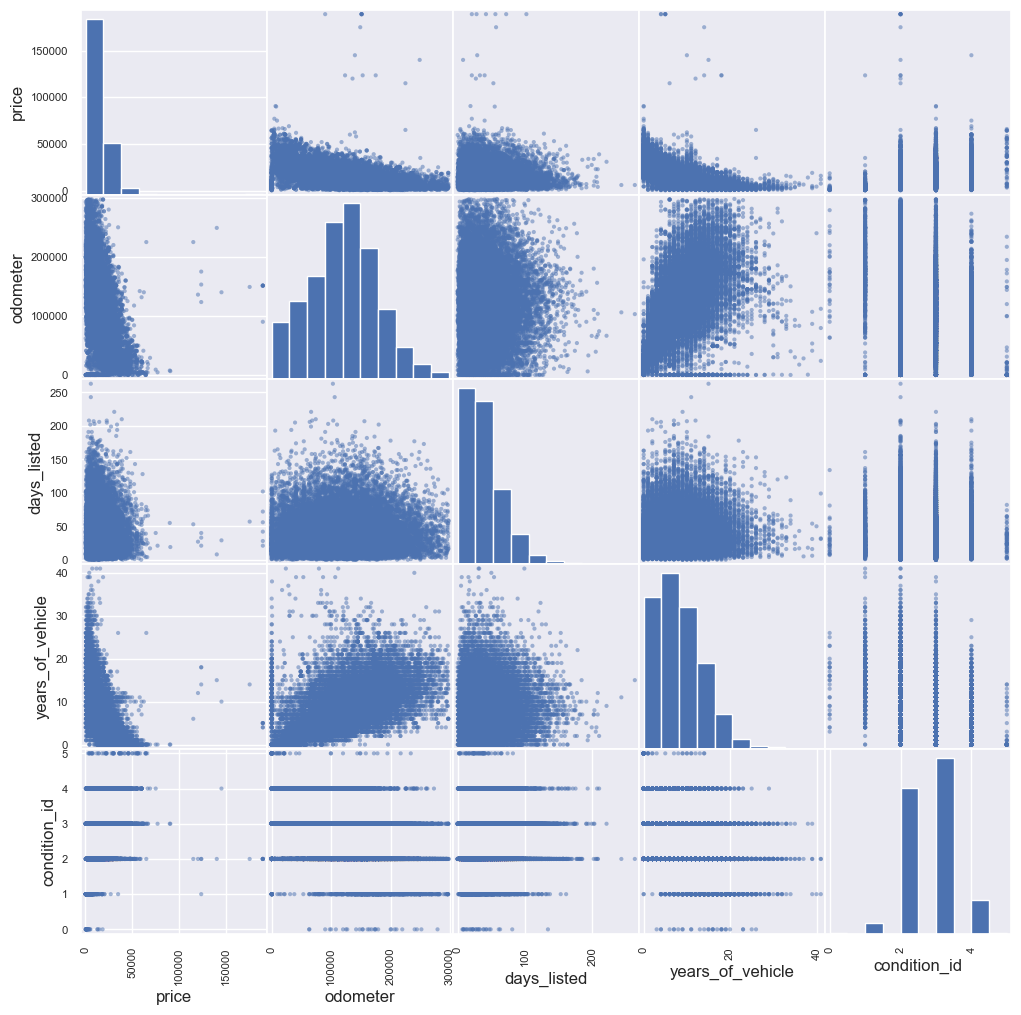

In [102]:
pd.plotting.scatter_matrix(df_vehicles_corr, figsize=(12, 12))

- Se verifica una relación indirecta entre el precio y la edad del vehículo. Es decir, mientras más edad tiene el auto el precio es menor.
- Se verifica una relación indirecta entre el millaje y el precio del vehículo. Es decir, mientras más recorrido tiene el auto el precio es menor.
- Se verifica una relación directa entre el precio de los vehículos y la condición. Mientras mejor es la condición del vehículo mayor es el precio.

Finalmente, se verifica una relación directa entre la edad de los vehículos y el millaje. Aunque esta relación era de esperarse y no es objeto del estudio, se considera oportuno mencionarlo.

#### Revisemos a detalle el comportamiento de estas relaciones en cada uno de los tipos de vehículos identificados como los más populares.

<Axes: title={'center': 'Precio como función de la edad para los tipos de vehículos más populares'}, xlabel='años', ylabel='Dólares'>

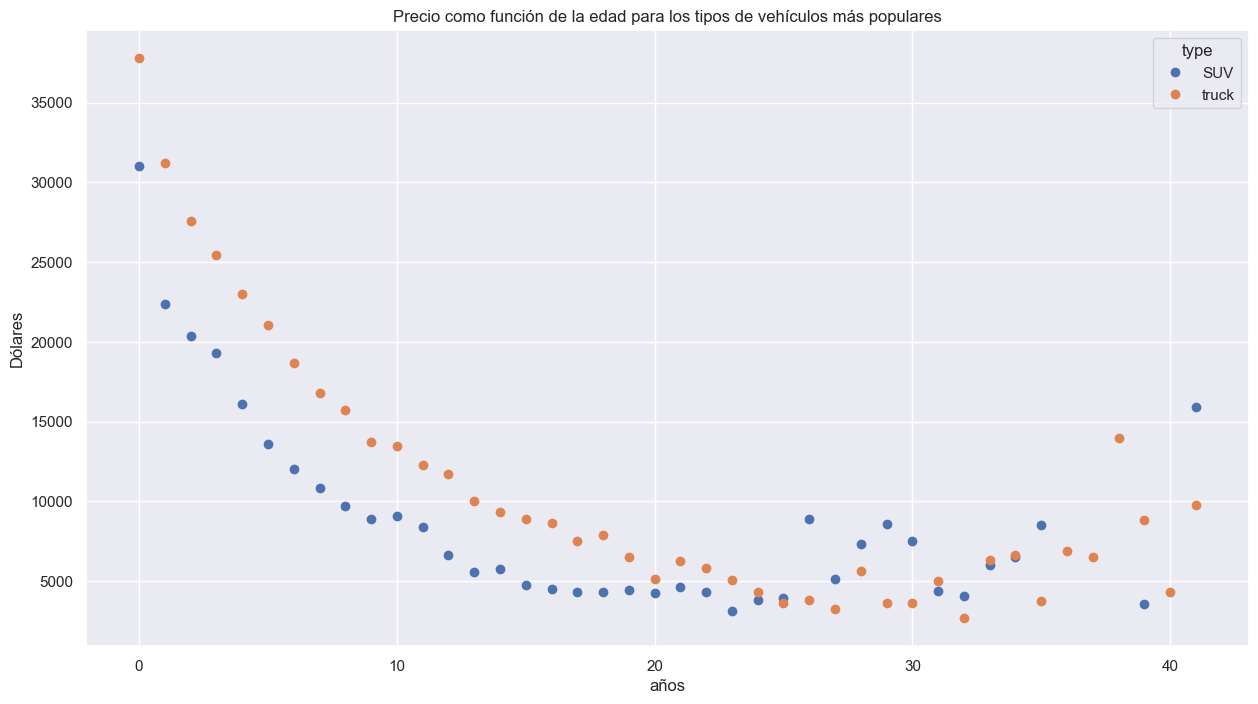

In [103]:
frame_years_posted_con = df_vehicles_corr.pivot_table(index='years_of_vehicle', columns='type', values='price')
frame_years_posted_con.plot(style="o", xlabel='años', ylabel='Dólares', title='Precio como función de la edad para los tipos de vehículos más populares')

<Axes: title={'center': 'Precio como función del millaje para los tipos de vehículos más populares'}, xlabel='millas', ylabel='Dólares'>

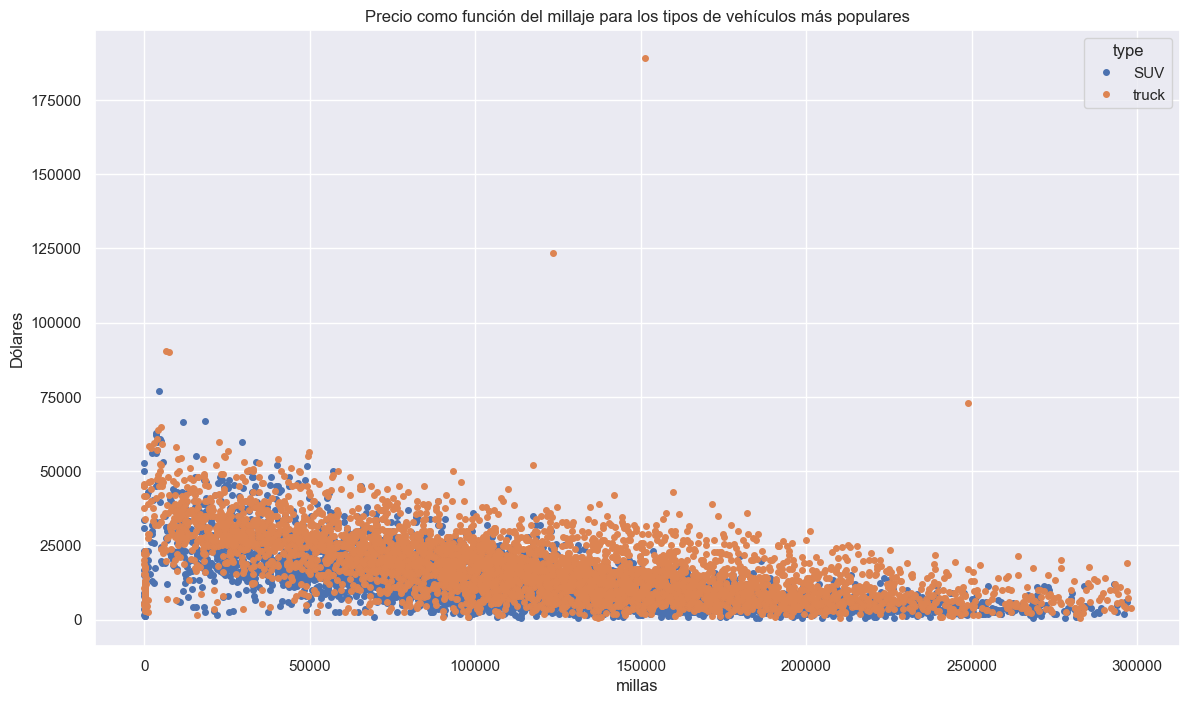

In [104]:
frame_odometer_con = df_vehicles_corr.pivot_table(index='odometer', columns='type', values='price')
frame_odometer_con.plot(style="o", figsize=(14,8), ms=4, xlabel='millas', ylabel='Dólares', title='Precio como función del millaje para los tipos de vehículos más populares') 

<Axes: title={'center': 'Precio como función de la condición para los tipos de vehículos más populares'}, xlabel='Condición', ylabel='Dólares'>

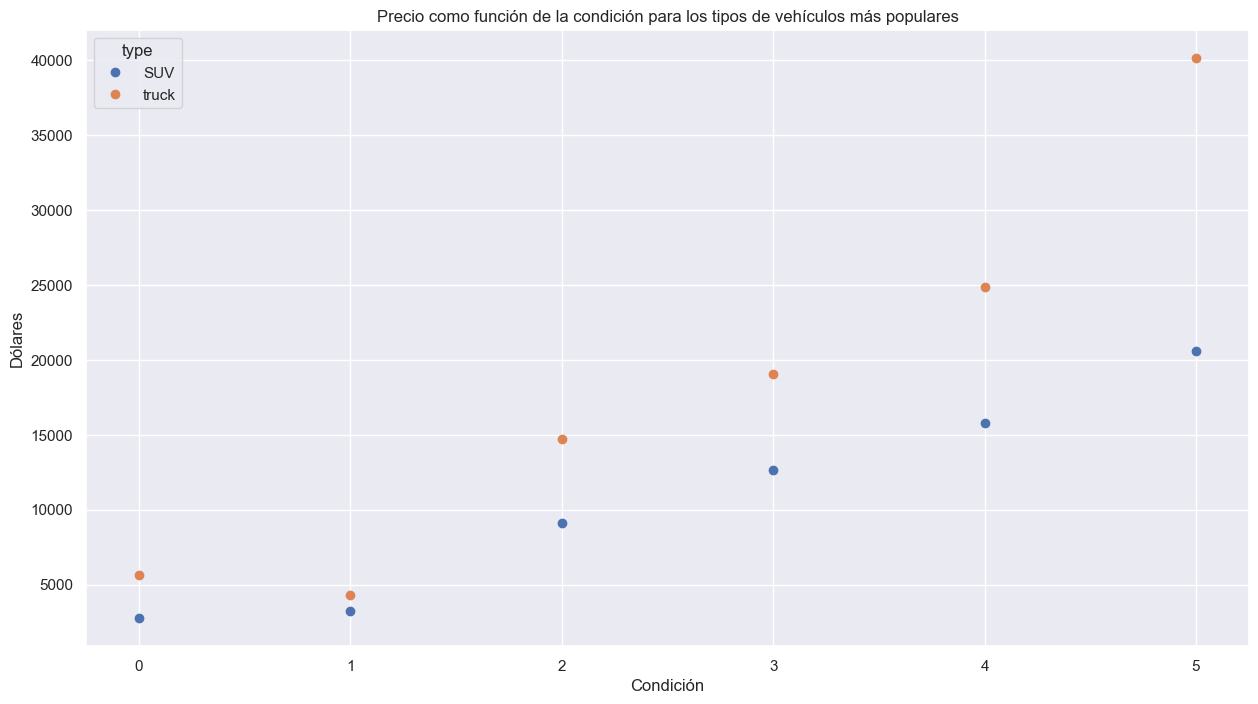

In [105]:
frame_condition_con = df_vehicles_corr.pivot_table(index='condition_id', columns='type', values='price')
frame_condition_con.plot(style="o", xlabel='Condición', ylabel='Dólares', title='Precio como función de la condición para los tipos de vehículos más populares') 

### Análisis de las variables categóricas

[Text(0.5, 1.0, 'Distribución del precio por tipo transmsion')]

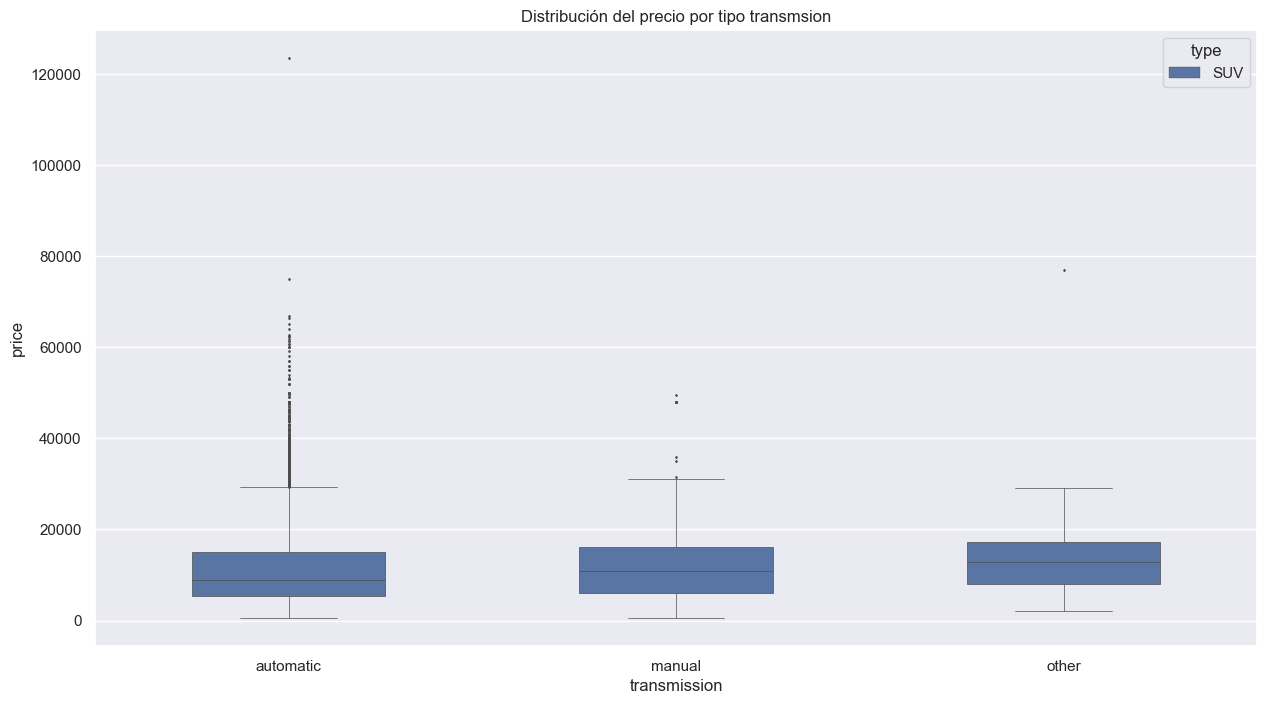

In [106]:
# Grafica de cajas por tipo de transmision de vehículo.
df_corr_trans_SUV = df_vehicles_corr.query('type == "SUV"')
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_corr_trans_SUV, x='transmission', y='price', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del precio por tipo transmsion')

[Text(0.5, 1.0, 'Distribución del precio por tipo transmsion')]

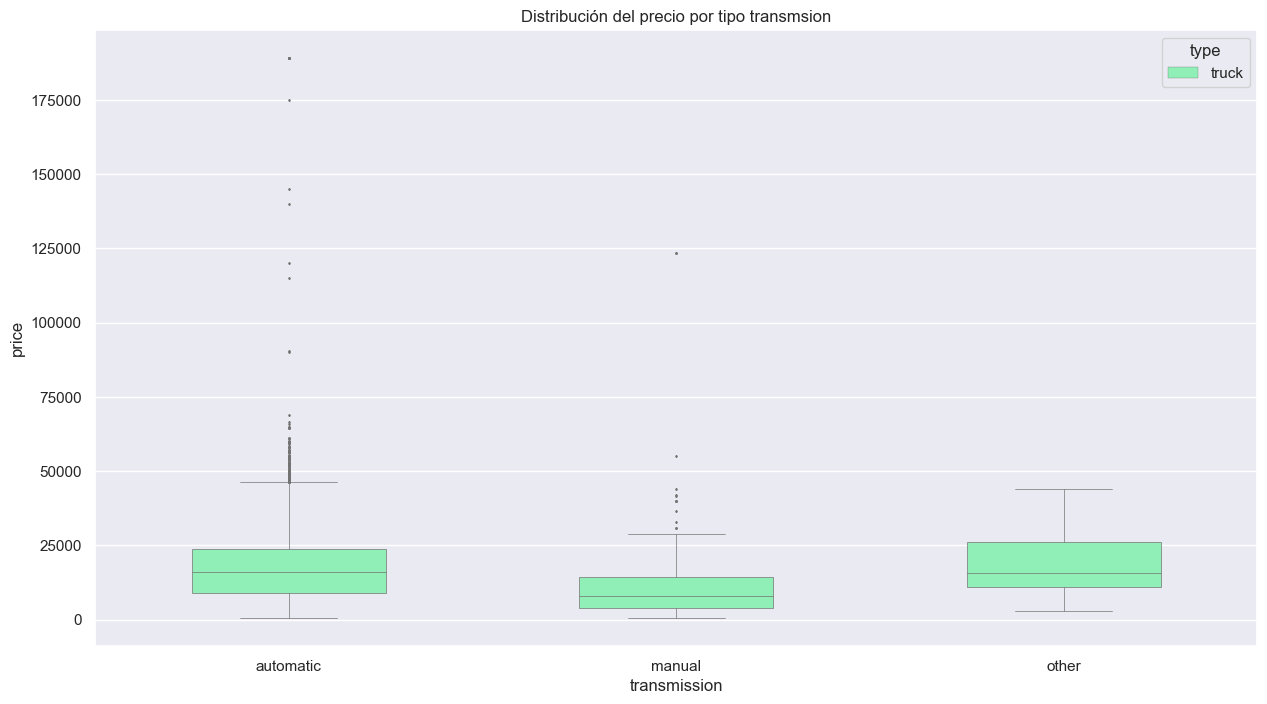

In [107]:
# Grafica de cajas por tipo de transmision de vehículo.
df_corr_trans_truck = df_vehicles_corr.query('type == "truck"')
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_corr_trans_truck, palette='rainbow', x='transmission', y='price', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del precio por tipo transmsion')

Esta variable parece no tener ningún efecto sobre el precio ya que se aprecia prácticamente el mismo comportamiento. Sin embargo, la categoría **transmisión automática** registra valores atípicos que reflejan una leve tendencia a tener precios más elevados que las otras dos categorías.

[Text(0.5, 1.0, 'Distribución del precio por tipo de color')]

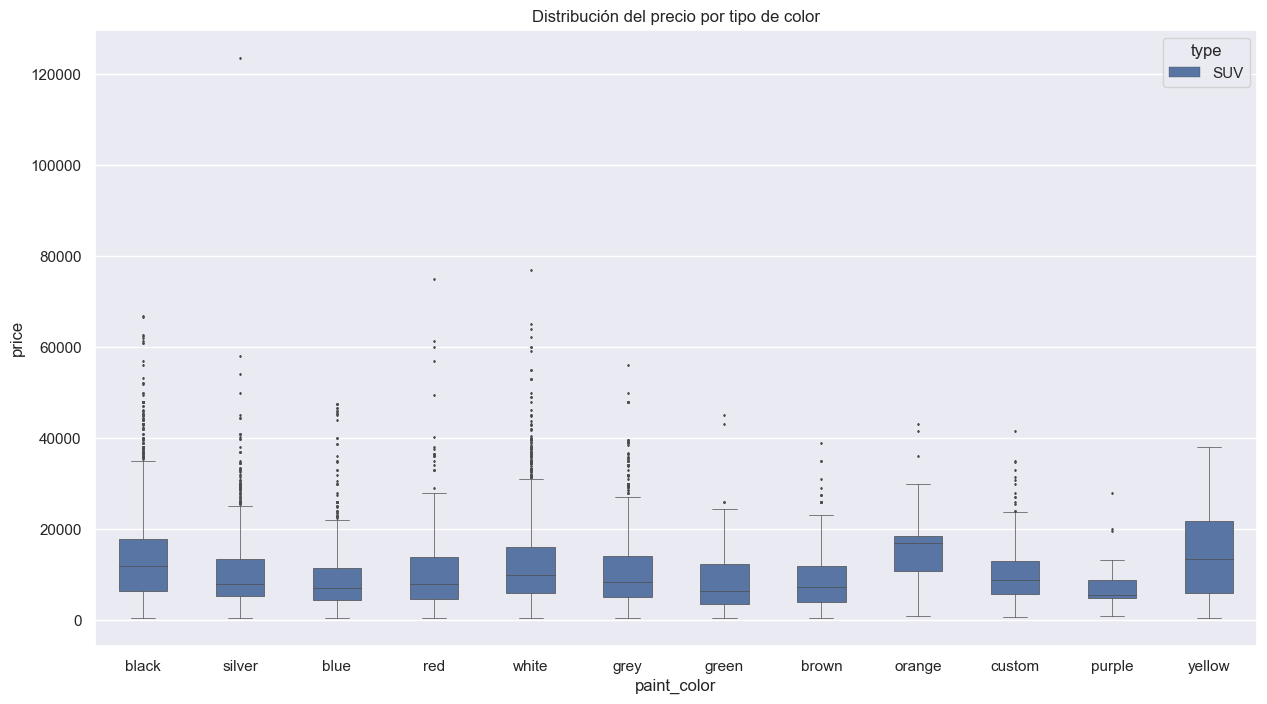

In [108]:
# Grafica de cajas por tipo de color de vehículo.
df_corr_SUV = df_vehicles_corr.query('type == "SUV"')
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_corr_SUV, x='paint_color', y='price', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del precio por tipo de color')

[Text(0.5, 1.0, 'Distribución del precio por tipo de color')]

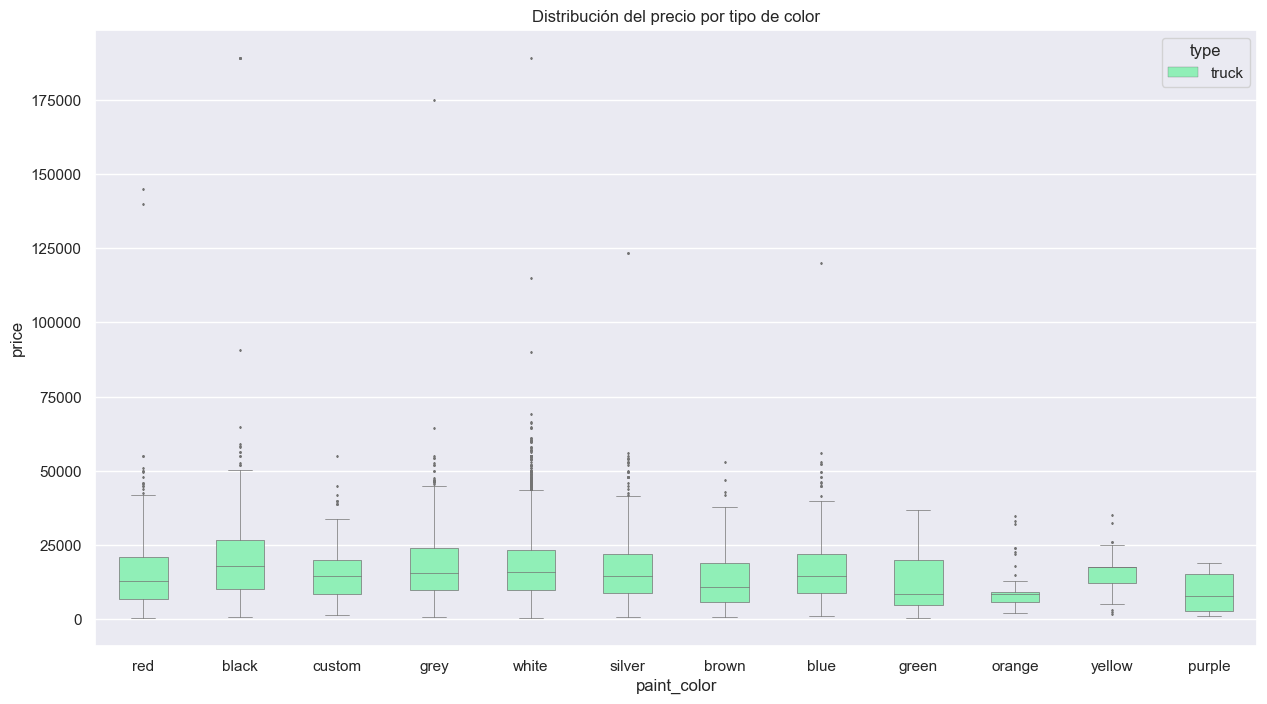

In [109]:
# Grafica de cajas por tipo de color de vehículo.
df_corr_truck = df_vehicles_corr.query('type == "truck"')
sns.set(rc = {'figure.figsize':(15,8)})
sns.boxplot(data=df_corr_truck, x='paint_color', y='price', palette='rainbow', hue='type', fliersize=1, width=0.5, linewidth=0.5, dodge=False).set(title='Distribución del precio por tipo de color')

No es posible identificar ningún patrón que permita establecer alguna relación entre estas variables.

## Conclusión general

-	El dataset contenía cinco columnas de trece con valores ausentes que pudieron reemplazarse con valores obtenidos de manera indirecta de otras variables.
-	Se identificó que una de estas columnas con valores ausentes tenía asignado un tipo de dato equivocado y debía reemplazarse por el tipo booleano. Los valores ausentes en realidad representaban efectivamente un valor válido.
-	Para verificar que no existieran patrones que provoquen la ausencia de datos se hizo una verificación de comparación de frecuencias relativas del dataset original y del dataset sin valores ausentes.
-	Las variables numéricas con valores ausentes se completaron con la mediana y los de las variables categóricas con la moda.
-	En los casos en los que a pesar de la utilización de les estadísticos mencionados no se pudo reemplazar los valores ausentes, fueron tratados manualmente.
-	Se encontraron duplicados implícitos en la columna *’model’*. Se procedió a corregirlos.
-	Se comprobó la existencia de valores atípicos utilizando la distribución de cada variable.
-	Se corrigió los tipos de dato de cinco variables, entre ellas, una que tenía datos *’Date Time’*.
-	Se calcularon dos nuevas columnas que servirían para el análisis de datos. Inclusive en una de estas columnas calculadas se encontraron valores ausentes producto del error de división por cero.
-	Se utilizaron principalmente histogramas, gráficos de cajas y bigotes y diagramas de dispersión para el análisis de las variables.
-	Se comprobó que luego de haber retirado los valores atípicos, la distribución del dataset no se alteró de manera significativa.
-	Se analizó la relación entre la cantidad de anuncios y la velocidad con la que se vendieron los vehículos sin encontrar patrones. Sin embargo, sí se comprobó que los vehículos que demoraron más en ser vendidos son mucho menos que aquellos que se vendieron rápidamente.
-	Se verificó que la cantidad de cuatro tipos de vehículos fue significativamente mayor que los otros tipos.
-	Se comprobó que no existe relación entre el precio de los vehículos y la cantidad de días publicados.
-	Se verificó que los factores que afectan al precio de los vehículos son la edad del vehículo, el millaje y la condición en la que se encuentra el vehículo.



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Gracias por enviar tu proyecto. Has hecho un excelente trabajo. 
Has respondido correctamente a la mayoría de las preguntas.

Destaco de tu trabajo que has sido muy extenso en las descripciones de datos y en la exploración gráfica. Tú trabajo queda aprobado. 

    
Ánimo, estoy seguro de que vas por un muy buen camino.


Gracias por tu trabajo. &#128077;
    
</div>
